# Functions

In [1]:
import pickle as pkl 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.optimize import fsolve
import matplotlib as mpl
import seaborn as sns 
import pandas as pd

mpl.use('Qt5Agg')

In [2]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 17

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)            # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 

In [3]:
def prechnage_haploid_wf(wA, wa, muAa, muaA): 
    """
    Returns the equilibrium frequency of a
    
    Parameters 
    ----------
    wA : relative fitness of A pre-change
    wa : relative fitness of a pre-change 
    muAa : mutation probability from A to a 
    maaA : mutation probability from a to A 
    
    Returns
    -------
    pa_equi : frequency of a at mutation-selection balance 
    """
    
    if wA - wa > (muAa + muaA) : 
        pa_equi = muAa/(wA - wa) 
    elif wa - wA > (muaA + muAa) :
        pa_equi = 1 - muaA/(wa - wA) 
    else: 
        pa_equi = muaA / (muAa + muaA)
    
    return pa_equi 
        
def Pres_haploid_wf(pAsgv,pasgv,muAa, maA, lamA, lama, Nstart): 
    """
    Returns the probability of survival post change 
    
    Parameters
    ----------
    pAsgv : frequency of A in the standing genetic variation (SGV)
    pasgv : frequency of a in the standing genetic variation (SGV)
    muAa : mutation probability from A to a post change
    muaA : mutation probability from a to A post change 
    lamA : absolute fitness of A post change 
    lama : absolute fitness of a post change 
    Nstart : population size at the change of environment
    
    Returns
    -------
    Pres : probability of the population surviving post change 
    """
    
    if pAsgv*lamA + pasgv*lama > 1: 
        Pres = 1 
    elif lama > 1 and lamA < 1:
        Nsgv = pasgv*Nstart
        Nmut = Nstart*lamA/(1-lamA)*muAa #Mutaion occurs after selection, hence the lamA factor in the numerator
        Pres = 1 - np.exp( -(Nsgv + Nmut)*2*(lama-1) )
    elif lamA > 1 and lama < 1 :
        Nsgv = pAsgv*Nstart
        Nmut = Nstart*lama/(1-lama)*muaA #Mutaion occurs after selection, hence the lama factor in the numerator
        Pres = 1 - np.exp( -(Nsgv + Nmut)*2*(lamA-1) )
    elif lama < 1 and lamA < 1: 
        Pres = 0
    else:
        print("Case not accounted for.")
    
    return Pres

    

In [4]:
def Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N):
    """
    Parameters
    ----------
    r : wildtype has absolute fitness 1-r
    """
    #Note mxenv (x=a,A;env=pre,post) refers to the effective rates \tilde{m}_{x,env} in the manuscript for this
    
    mueffpre = (1-mApre)*mu + mApre*nu 
    mueffpost = (1-mApost)*mu + mApost*nu 
    paeff = mueffpre/((1-(mapre*hbpre+mApre*hBpre))*spre)
    if paeff < 0 :
        print('Negative')
    pest = 1 - np.exp(-2*((1-mapost*hbpost)*spost-r)) if (1-mapost*hbpost)*spost-r > 0 else 0
    Nsgv = paeff*N 
    
    if mApost*hBpost*spost-r < 0:    
        Ndenovo = mueffpost/(r-mApost*hBpost*spost)*(1-paeff)*N
        Pgen = 1 - (1-pest)**(Nsgv + Ndenovo) if (1-mapost*hbpost)*spost-r > 0 else 0
    else:
        Ndenovo = np.inf 
        Pgen = 1 if (1-mapost*hbpost)*spost-r > 0 and mueffpost > 0 else 0
    
    Nwild = (1-paeff)*N
    Pepi = 1 - np.exp(-2*(mApost*hBpost*spost-r)*Nwild) if mApost*hBpost*spost-r > 0 else 0 
    
    if Pgen < 0 or Pepi < 0 : 
        print("Error", paeff, ", Pgen:",Pgen, ", Pepi:",Pepi, mueffpre, (1-(mapre*hbpre+mApre*hBpre))*spre)
    if Pgen > 1 or Pepi > 1: 
        print("Error", paeff, ", Pgen:",Pgen, ", Pepi:",Pepi, mueffpre, (1-(mapre*hbpre+mApre*hBpre))*spre)
    return 1 - (1-Pgen)*(1-Pepi), Ndenovo, pest

def prechange_haploid_det(spre,hbpre,hBpre,mapre,mApre,tapre,tApre,mu,nu,timeseries=False, NoG=10**5):
    pA = 1
    pB = 0 
    pa = 0
    pb = 0 
    
    wA = 1
    wa = 1-spre
    wB = 1-hBpre*spre
    wb = 1-(1-hbpre)*spre
    
    gen = 0
    
    if timeseries: 
        pAlist = [pA]
        pBlist = [pB]
        palist = [pa]
        pblist = [pb] 
        
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = wA*pA
        pas = wa*pa
        pBs = wB*pB
        pbs = wb*pb
        
        pAmut = (1-mApre)*(1-mu)*pAs + tApre*(1-nu)*pBs + mu*pas 
        pamut = (1-mapre)*(1-mu)*pas + tapre*(1-nu)*pbs + mu*pAs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pAs + nu*pbs
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pas + nu*pBs
        
        wavg = pAmut + pamut + pBmut + pbmut
        
        pAnext = pAmut/wavg
        pBnext = pBmut/wavg
        panext = pamut/wavg
        pbnext = 1-pAnext-pBnext-panext
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pB = pBnext 
        pa = panext 
        pb = pbnext 
        
        if timeseries: 
            pAlist += [pA]
            pBlist += [pB]
            palist += [pa]
            pblist += [pb]
    if timeseries: 
        return [pAlist, palist, pBlist, pblist, pAnext, panext, pBnext, pbnext]
    return [pAnext,panext,pBnext,pbnext]

def postchange_haploid_stoch(pA,pB,pa,pb,spost,rpost,hpost_list,mapost,mApost,tapost,tApost,N_start,mu,nu,timeseries=False) :
    """
    
    Parameters
    ----------
    spre : float (positive)
    spost : float (positive)
    rpost : float (positive)
    hpre_list : list of length 
    hpost_list : list of length
    mapre : float (between 0 and 1)
    mApre : float (between 0 and 1)
    tapre : float (between 0 and 1)
    tApre : float (between 0 and 1)
    mapost : float (between 0 and 1)
    mApost : float (between 0 and 1)
    tapost : float (between 0 and 1)
    tApost : float (between 0 and 1)
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    np.random.seed()
    
    lamA,lama,lamB,lamb = 1 - rpost + np.array(hpost_list)*spost
    #print(lamA, lama, lamB, lamb)
    
    
    Ext = 0 
    
    NA = round(pA*N_start)
    NB = round(pB*N_start)
    Na = round(pa*N_start)
    Nb = round(pb*N_start)
    
    NAlist = [NA]  
    NBlist = [NB]
    Nalist = [Na]
    Nblist = [Nb]
    
    
    while True: 
        N_tot = NA + NB + Na + Nb     
        
        if N_tot == 0:
            Ext = 1
            break
        elif N_tot > 2*max(N_start, 10**4): 
            break
        
        pA = NA/float(N_tot)
        pB = NB/float(N_tot)
        pa = Na/float(N_tot)
        pb = Nb/float(N_tot)
        
        NAs = lamA*NA
        Nas = lama*Na
        NBs = lamB*NB
        Nbs = lamb*Nb
        
        #print(NAs,NBs,Nas,Nbs)
        
        NAmut = (1-mApost)*(1-mu)*NAs + tApost*(1-nu)*NBs + mu*Nas 
        Namut = (1-mapost)*(1-mu)*Nas + tapost*(1-nu)*Nbs + mu*NAs 
        NBmut = (1-tApost)*(1-nu)*NBs + mApost*(1-mu)*NAs + nu*Nbs
        Nbmut = (1-tapost)*(1-nu)*Nbs + mapost*(1-mu)*Nas + nu*NBs
        #print((1-tapost)*(1-nu)*Nbs,  mapost*(1-mu)*Nas, nu*NBs, Nbmut)
        
        NA = np.random.poisson(NAmut)
        NB = np.random.poisson(NBmut)
        Na = np.random.poisson(Namut)  
        Nb = np.random.poisson(Nbmut)
        
        if timeseries: 
            NAlist += [NA]
            NBlist += [NB]
            Nalist += [Na]
            Nblist += [Nb]
        
    if timeseries: 
        return [NAlist, Nalist, NBlist, Nblist, Ext]
    
    return Ext


6741


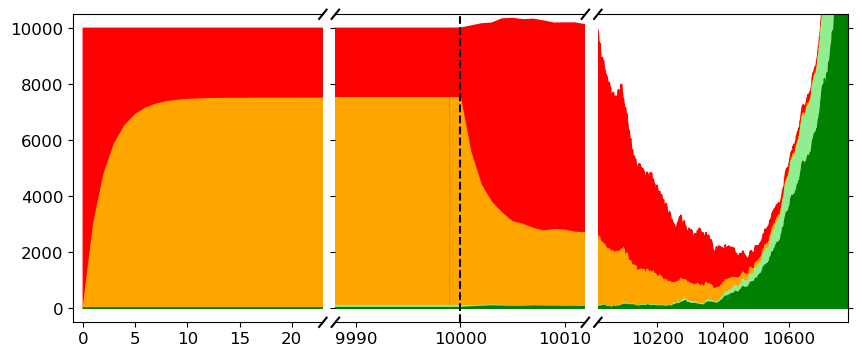

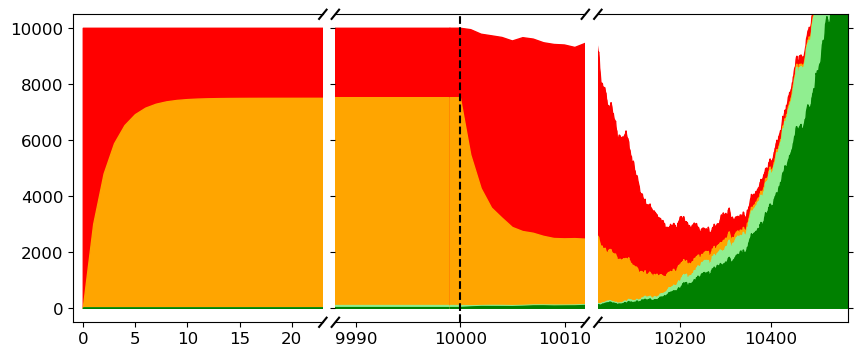

In [6]:
%matplotlib inline
seed = int(np.random.random()*10**4)
print(seed)
np.random.seed(seed)#5882 #178


N=10**4

spre=0.01
hbpre=0.8
hBpre=0.1
mpre = 0.3
tpre = 0.1

r=0.01
spost=0.02
hbpost, hBpost = (1-r/spost)/0.7,(r/spost)/0.9
mu = 10**(-4.5)
nu = 10**(-4.5)
mpost = 0.1
tpost = 0.3


pAlist, palist, pBlist, pblist, pA, pa, pB, pb = prechange_haploid_det(spre=spre,hbpre=hbpre,hBpre=hBpre,mapre=mpre,mApre=mpre,tapre=tpre,tApre=tpre,mu=mu,nu=nu,timeseries=True, NoG=10**5)
NAlist, Nalist, NBlist, Nblist, Ext = postchange_haploid_stoch(pA=pA,pB=pB,pa=pa,pb=pb,spost=spost,rpost=r,hpost_list=[0,1,hbpost,hBpost],mapost=mpost,mApost=mpost,tapost=tpost,tApost=tpost,N_start=N,mu=mu,nu=nu,timeseries=True)

change_gen = 10000
break_gen = 20

Napre = np.array(palist[:change_gen])*N 
Nabpre = (np.array(palist[:change_gen])+np.array(pblist[:change_gen]))*N 
NabBpre = (np.array(palist[:change_gen])+np.array(pblist[:change_gen])+np.array(pBlist[:change_gen]))*N 
NabBApre = (np.array(palist[:change_gen])+np.array(pblist[:change_gen])+np.array(pBlist[:change_gen])+np.array(pAlist[:change_gen]))*N 

Napost = np.array(Nalist)
Nabpost = np.array(Nalist)+np.array(Nblist)
NabBpost = np.array(Nalist)+np.array(Nblist)+np.array(NBlist)
NabBApost = np.array(Nalist)+np.array(Nblist)+np.array(NBlist)+np.array(NAlist)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(10,4), gridspec_kw={'wspace':0.05})

ax1.fill_between(range(change_gen), np.array(NabBApre[:change_gen]), color ='red')
ax1.fill_between(range(change_gen), np.array(NabBpre[:change_gen]), color ='orange')
ax1.fill_between(range(change_gen), np.array(Nabpre[:change_gen]), color ='lightgreen')
ax1.fill_between(range(change_gen), np.array(Napre[:change_gen]), color ='green')

ax1.fill_between(range(change_gen-1,len(NabBApost)+change_gen), [NabBApre[-1]] + list(NabBApost), color = 'red')
ax1.fill_between(range(change_gen-1,len(NabBpost)+change_gen), [NabBpre[-1]] + list(NabBpost), color = 'orange')
ax1.fill_between(range(change_gen-1,len(Nabpost)+change_gen), [Nabpre[-1]] + list(Nabpost), color = 'lightgreen')
ax1.fill_between(range(change_gen-1,len(Napost)+change_gen), [Napre[-1]] + list(Napost), color = 'green')

ax2.fill_between(range(change_gen), np.array(NabBApre[:change_gen]), color ='red')
ax2.fill_between(range(change_gen), np.array(NabBpre[:change_gen]), color ='orange')
ax2.fill_between(range(change_gen), np.array(Nabpre[:change_gen]), color ='lightgreen')
ax2.fill_between(range(change_gen), np.array(Napre[:change_gen]), color ='green')

ax2.fill_between(range(change_gen-1,len(NabBApost)+change_gen), [NabBApre[change_gen-1]] + list(NabBApost), color = 'red')
ax2.fill_between(range(change_gen-1,len(NabBpost)+change_gen), [NabBpre[change_gen-1]] + list(NabBpost), color = 'orange')
ax2.fill_between(range(change_gen-1,len(Nabpost)+change_gen), [Nabpre[change_gen-1]] + list(Nabpost), color = 'lightgreen')
ax2.fill_between(range(change_gen-1,len(Napost)+change_gen), [Napre[change_gen-1]] + list(Napost), color = 'green')

ax3.fill_between(range(change_gen), np.array(NabBApre[:change_gen]), color ='red')
ax3.fill_between(range(change_gen), np.array(NabBpre[:change_gen]), color ='orange')
ax3.fill_between(range(change_gen), np.array(Nabpre[:change_gen]), color ='lightgreen')
ax3.fill_between(range(change_gen), np.array(Napre[:change_gen]), color ='green')

ax3.fill_between(range(change_gen-1,len(NabBApost)+change_gen), [NabBApre[-1]] + list(NabBApost), color = 'red')
ax3.fill_between(range(change_gen-1,len(NabBpost)+change_gen), [NabBpre[-1]] + list(NabBpost), color = 'orange')
ax3.fill_between(range(change_gen-1,len(Nabpost)+change_gen), [Nabpre[-1]] + list(Nabpost), color = 'lightgreen')
ax3.fill_between(range(change_gen-1,len(Napost)+change_gen), [Napre[-1]] + list(Napost), color = 'green')

ax2.axvline(x=change_gen, color='black', linestyle = 'dashed')

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.yaxis.tick_left()
ax2.yaxis.tick_right()
ax2.yaxis.tick_left()
ax3.yaxis.tick_right()

ax1.set_ylim([-500,10**4+500])
ax2.set_ylim([-500,10**4+500])

ax1.set_xlim(-1, break_gen+3)
ax2.set_xlim(change_gen-12,change_gen+12)
ax3.set_xlim(change_gen+20,len(Napost)+change_gen)

d = 0.015  # diagonal line size
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)  
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)  
ax2.plot((-d, +d), (-d, +d), **kwargs)

kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)  = m_A' = t_A' = 0.8
ax3.plot((-d, +d), (-d, +d), **kwargs)

plt.savefig('Popdyn.svg',format='svg')

## Quasi Epigenetic Equilibrium - Haploid

seed 831


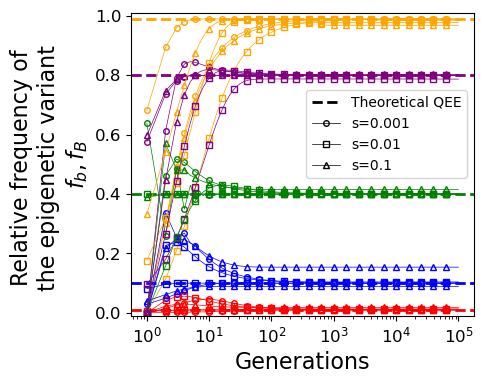

In [5]:
x_range = [0.01,0.1,0.4,0.8,0.99]    
svalues = [0.001,0.01, 0.1]

colors = ['red','blue','green','purple','orange']
mkrs = ['o','s','^']

%matplotlib inline
fig = plt.figure(figsize=(5,4))

seed = round(np.random.random()*1000)
print("seed",seed)
np.random.seed(823) #989 #823 #30
for x_ind, x in enumerate(x_range): 
    x = round(x,3)
    plt.axhline(y=x, linestyle = '--', color=colors[x_ind], linewidth=2)
    for spre_ind, spre in enumerate(svalues): 
        for rep in range(1): 
            mA = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
            tA = (1-x)*mA/x if x != 0 else np.random.random()
            xa = x_range[x_ind-1]
            ma = np.random.random()*min(xa/(1-xa),1) if xa != 1 else np.random.random()
            ta = (1-xa)*ma/xa if xa != 0 else np.random.random()
            
            hbpre = np.random.random() 
            hBpre = np.random.random() 
            mu = 10**(-6)
            nu = 10**(-6)
            output = prechange_haploid_det(spre=spre,hbpre=hbpre,hBpre=hBpre,mapre=ma,mApre=mA,tapre=ta,tApre=tA,mu=mu,nu=nu,timeseries=True)
            mnorm_A = np.array(output[2])/(np.array(output[0]) + np.array(output[2])) 
            mnorm_a = np.array(output[3])/(np.array(output[1]) + np.array(output[3])) 
            mkevry = [round(10**exp)-1 for exp in np.arange(0,5,0.2)] 
            plt.plot( range(1,1+len(mnorm_A)), mnorm_A, ms=4, markevery= mkevry, marker=mkrs[spre_ind] , fillstyle = 'none', color = colors[x_ind], linewidth = 0.5) 
            plt.plot( range(1,1+len(mnorm_a)), mnorm_a, ms=4, markevery= mkevry, marker=mkrs[spre_ind] , fillstyle = 'none', color = colors[x_ind-1], linewidth = 0.5) 
            
            #plt.plot( range(len(mnorm_a)), mnorm_a, color = colors[x_ind] ) 
    
plt.plot([0],[0],label='Theoretical QEE', color = 'black', linestyle = '--', linewidth=2)

for spre_ind, spre in enumerate(svalues):
    plt.plot( [-1], [-1], ms=4, marker=mkrs[spre_ind] , fillstyle = 'none', color = 'black', linewidth = 0.5, label = "s="+str(spre))     



plt.xlabel("Generations", fontsize = 16)
plt.ylabel("Relative frequency of \n"+"the epigenetic variant \n"+r"$f_b, f_B$", fontsize = 16)
plt.legend(fontsize = 10, loc = "center right", bbox_to_anchor=(1,0.6))
plt.ylim(-0.01,1.01)
#plt.xlim(1,1000)
plt.xscale('log')
plt.tight_layout()
plt.savefig("QEEVerification.png",format="png")



## Pre-change Equilibrium - Haploid

In [56]:
spre = 0.01 
mu = 10**(-6)
nu = 10**(-6)
mnorm_range = np.arange(0,1,0.01)
hsum_range = np.arange(0,1.01,0.05)

outfile = open("GeneralModel_WF_Equilibria_spre" + str(spre) +".txt", "w")

for hsum in hsum_range: 
    hsum = round(hsum,3)
    print(hsum)
    for mnorm in mnorm_range:
        hbpre = np.random.random()*hsum
        hBpre = hsum - hbpre
        
        m = np.random.random()*min(mnorm/(1-mnorm),1) if mnorm != 1 else np.random.random()
        m=round(m,4)
        t = (1-mnorm)*m/mnorm if mnorm != 0 else np.random.random()
        t=round(t,4)
        
        pA, pa, pB, pb = prechange_haploid_det(spre,hbpre,hBpre,m,m,t,t,mu,nu, NoG=10**4)
        x = 0 if m+t == 0 else m/(m+t)
        outfile.write(str(spre)+ " "+ str(hbpre)+" " + str(hBpre) + " " + str(m) + " " + str(t) + " " + str(x)+ " " + str(pA) + " " + str(pa) + " " + str(pB) + " " + str(pb) +  "\n")

outfile.close() 

0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95
1.0


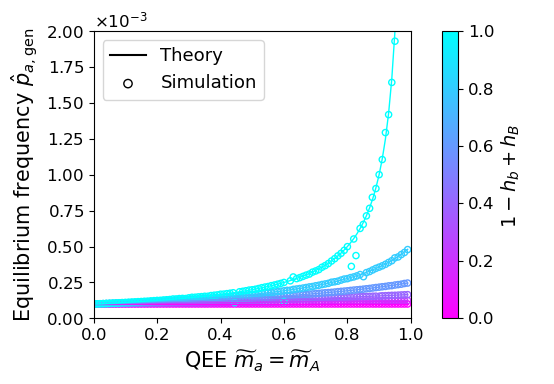

In [6]:
equi = np.loadtxt("GeneralModel_WF_Equilibria_spre" + str(0.01) +".txt")

%matplotlib inline

cmap = mpl.colormaps['cool_r']
fig, ax = plt.subplots(1, 2, gridspec_kw={'width_ratios': [10, 0.5]}, figsize = (5.7,4) )

for sm in np.arange(0,1.01,0.2):
    sm = round(sm,4)
    inds = np.logical_and(equi[:,1] + equi[:,2] < sm + 0.01, equi[:,1] + equi[:,2] > sm - 0.01)
    ax[0].scatter(equi[inds,5],equi[inds,7]+equi[inds,9],edgecolors=cmap(sm),c='none',s=20 )
    mu = 10**(-6)
    ax[0].plot(np.arange(0,1,0.01), [mu/((1-mnorm*sm)*0.01) for mnorm in np.arange(0,1,0.01)], color = cmap(sm), linewidth =1)

ax[0].set_ylim([0,0.002])
ax[0].set_xlim([0,1])
ax[0].set_xlabel(r'QEE $\widetilde{m}_a = \widetilde{m}_A$', fontsize = 15)
ax[0].set_ylabel(r'Equilibrium frequency $\hat{p}_{a,{\text{gen}}}$', fontsize = 15)
ax[0].plot([-1],[-1],label = 'Theory',color='black')
ax[0].scatter([-1],[-1],label = 'Simulation',c = 'none', edgecolors='black')
ax[0].legend(fontsize=13)
ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax[0].yaxis.major.formatter._useMathText = True


cb = mpl.colorbar.ColorbarBase(ax[1], cmap=cmap, orientation='vertical')
ax[1].set_ylabel(r'$1 -h_b + h_B$' +' \n')
plt.tight_layout()
plt.savefig("PrechangeEqui.png",format='png')
plt.show()

## Rescue probability - Pure Epigenetics (Haploid)

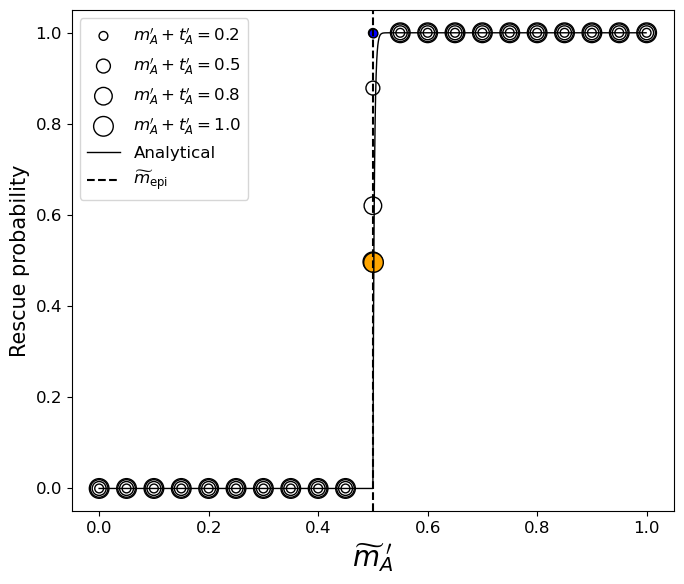

In [32]:
path = "/home/puneeth/UofT/Projects/Epigenetic Project/Code/Haploid_Epigenetics/PureEpigenetic_Data/"
m_range = np.arange(0.05,1.05,0.05)
t_range = np.arange(0.05,1.05,0.05)

r = 0.01
spre = 0.01
spost = 0.02
hbpre=0
hBpre=1
hbpost=0
hBpost=1
mu = 0
nu = 0 

mapre = 0.1
mApre = 0.1

%matplotlib inline        

N=10000
plt.figure(figsize = (7,6))

x_theoretical = np.arange(0,1,0.001)
y_theoretical = [] 
for x in x_theoretical:
    mApost = x 
    mapost = 0 
    mApre = x
    mapre = 0
    y_theoretical += [Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0]]
    
for ma in [0.2,0.5,0.8,1.0]:
    HaploidERwriter = pd.ExcelFile('./DataFiles/Haploid_ER_PE0_'+str(ma)+'.xlsx')
    HaploidDF = pd.read_excel(HaploidERwriter, sheet_name = str(ma) ,index_col=0)
    HaploidDF = HaploidDF.transpose()
    plt.scatter(np.arange(0,1.05,0.05),1-np.array(HaploidDF[ma]), edgecolor = 'black', color = 'none', s=ma*200, label = "$m_A'+t_A'=$"+str(ma))
    if ma == 0.2:
        plt.scatter([0.5],1-np.array(HaploidDF[ma][0.5]), edgecolor = 'black', color = 'blue', s=ma*200)
    if ma == 1:
        plt.scatter([0.5],1-np.array(HaploidDF[ma][0.5]), edgecolor = 'black', color = 'orange', s=ma*200)
plt.plot(x_theoretical, y_theoretical, color='black', linewidth = 1, label = 'Analytical')
plt.axvline(x=r/(spost),linestyle = '--', color = 'black', label ='$\widetilde{m}_\\text{epi}$')

plt.xlabel(r"$\widetilde{m}_A\hspace{-0.3}'$", fontsize = 20)
plt.ylabel("Rescue probability", fontsize = 15)
plt.legend()
plt.tight_layout() 
plt.savefig("PureEpi_SurProb.png",format = "png")
plt.show()

In [26]:
HaploidDF[ma]

0.00    1.00000
0.05    1.00000
0.10    1.00000
0.15    1.00000
0.20    1.00000
0.25    1.00000
0.30    1.00000
0.35    1.00000
0.40    1.00000
0.45    1.00000
0.50    0.00034
0.55    0.00000
0.60    0.00000
0.65    0.00000
0.70    0.00000
0.75    0.00000
0.80    0.00000
0.85    0.00000
0.90    0.00000
0.95    0.00000
1.00    0.00000
Name: 0.2, dtype: float64

1630


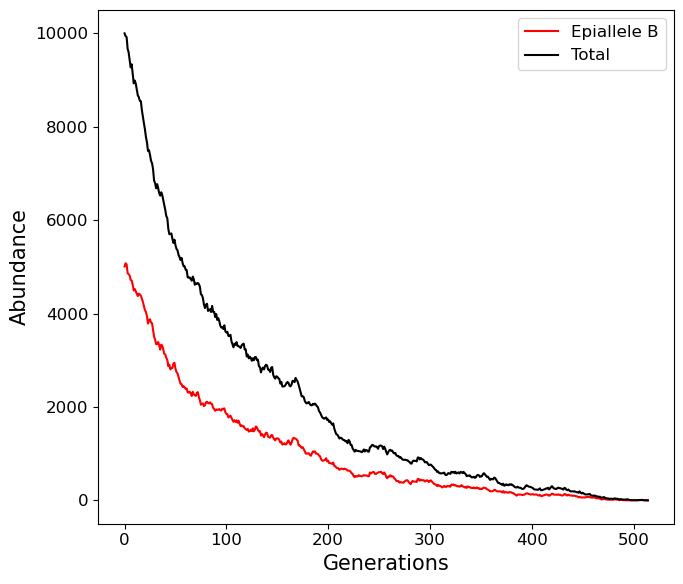

In [166]:
rpost=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1

t = 0.1
m = 0.1
mApre = 0.8
mApost = m 
tApre = 0.8 
tApost = t 

hBpost = 1
hbpost = 0

mu = 0 
nu = 0 

mapre = 0 
mapost = 0
tapre = 1 #Doesn't matter what values this takes. Just needs to be non-zero so that the code doesn't breakdown 
tapost = 1 #Doesn't matter what values this takes. Just needs to be non-zero so that the code doesn't breakdown


N = 10000

for n in range(1):
    sd = int(np.random.random()*10000)
    print(sd)
    np.random.seed(sd)

    pAlist, palist, pBlist, pblist, pA, pa, pB, pb = prechange_haploid_det(spre=spre,hbpre=hbpre,hBpre=hBpre,mapre=mapre,mApre=mApre,tapre=tapre,tApre=tApre,mu=mu,nu=nu,timeseries=True, NoG=10**5)
    NA_list, Na_list, NB_list, Nb_list, Ext = postchange_haploid_stoch(pA=pA,pB=pB,pa=pa,pb=pb,spost=spost,rpost=r,hpost_list=[0,1,hbpost,hBpost],mapost=mapost,mApost=mApost,tapost=tapost,tApost=tApost,N_start=N,mu=mu,nu=nu,timeseries=True)
    if Ext == 0: 
        break 
    %matplotlib inline
plt.figure(figsize = (7,6))
plt.plot(range(len(NB_list)), NB_list, color = 'red', label = "Epiallele B" )
plt.plot(range(len(NB_list)), np.array(NB_list)+np.array(NA_list), color = 'black', label = "Total" )
plt.legend(fontsize = 12, loc = "upper right")
plt.ylabel("Abundance", fontsize = 15)
plt.xlabel("Generations", fontsize = 15)
plt.tight_layout()
plt.savefig("PureEpi_PopDyn.png",format="png")

In [236]:
import numpy as np
import multiprocessing as mp 
import pandas as pd 
import sys 

def Haploid_PreChange(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,NoG = 10**5, timeseries = False): 
    
    wA,wa,wB,wb = 1-np.array(hpre_list)*spre 
    
    pA = 1
    pB = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = wA*pA
        pBs = wB*pB
        
        pAmut = (1-mApre)*pAs + tApre*pBs
        pBmut = (1-tApre)*pBs + mApre*pAs
        
        wavg = pAmut + pBmut
        
        pAnext = pAmut/wavg
        pBnext = 1-pAnext
        
        if pAnext + pBnext > 1:
            print("Negatives imminent", pAnext + pBnext)     
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pB = pBnext 
        
        if pA < 0 or pB < 0 : 
            raise TypeError("Negativesss",pA,pB)
    
    return pA, pB
    
def Haploid(pA,pB,pa,pb,spost,rpost,hpost_list,mapost,mApost,tapost,tApost,N_start,mu,nu,timeseries=False) :
    """
    
    Parameters
    ----------
    spre : float (positive)
    spost : float (positive)
    rpost : float (positive)
    hpre_list : list of length 
    hpost_list : list of length
    mapre : float (between 0 and 1)
    mApre : float (between 0 and 1)
    tapre : float (between 0 and 1)
    tApre : float (between 0 and 1)
    mapost : float (between 0 and 1)
    mApost : float (between 0 and 1)
    tapost : float (between 0 and 1)
    tApost : float (between 0 and 1)
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    
    np.random.seed()
    
    lamA,lama,lamB,lamb = 1 - rpost + np.array(hpost_list)*spost
    #print(lamA, lama, lamB, lamb)
    
    
    Ext = 0 
    
    NA = round(pA*N_start)
    NB = round(pB*N_start)
    Na = round(pa*N_start)
    Nb = round(pb*N_start)
    
    NAlist = [NA]  
    NBlist = [NB]
    Nalist = [Na]
    Nblist = [Nb]
    
    
    while True: 
        N_tot = NA + NB + Na + Nb     
        
        if N_tot == 0:
            Ext = 1
            break
        elif N_tot > 2*max(N_start, 10**4): 
            break
        
        pA = NA/float(N_tot)
        pB = NB/float(N_tot)
        pa = Na/float(N_tot)
        pb = Nb/float(N_tot)
        
        NAs = lamA*NA
        Nas = lama*Na
        NBs = lamB*NB
        Nbs = lamb*Nb
        
        #print(NAs,NBs,Nas,Nbs)
        
        NAmut = (1-mApost)*(1-mu)*NAs + tApost*(1-nu)*NBs + mu*Nas 
        Namut = (1-mapost)*(1-mu)*Nas + tapost*(1-nu)*Nbs + mu*NAs 
        NBmut = (1-tApost)*(1-nu)*NBs + mApost*(1-mu)*NAs + nu*Nbs
        Nbmut = (1-tapost)*(1-nu)*Nbs + mapost*(1-mu)*Nas + nu*NBs
        #print((1-tapost)*(1-nu)*Nbs,  mapost*(1-mu)*Nas, nu*NBs, Nbmut)
        
        NA = np.random.poisson(NAmut)
        NB = np.random.poisson(NBmut)
        Na = np.random.poisson(Namut)  
        Nb = np.random.poisson(Nbmut)
        
        if timeseries: 
            NAlist += [NA]
            NBlist += [NB]
            Nalist += [Na]
            Nblist += [Nb]
        
    if timeseries: 
        return [NAlist, Nalist, NBlist, Nblist, Ext]
    
    return Ext


xtot = 1
#wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre 
#wAA = 0 wAB = 0.1 wBB = 0.2 wAa = 0.3 wAb = 0.4 waB = 0.5 wBb = 0.6 wbb = 0.7 wab = 0.8 waa = 1
rpost=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
#hbpost=0.625
#hBpost=0.3
mu=0
nu=0
N_start=10**4
NoR = 10**3


#xpre_range = np.arange(0,1.1,0.2)
xpost_range = np.arange(0,1.05,0.05)

hbpost, hBpost = 0,1
hpost_list = [0,1,hBpost,1-hbpost]

a = mp.cpu_count() - 2

ExtProb = [] 
Ext_row = []

mApre = 0.8
tApre = 0.8
mapre = 0.1
tapre = 0.9

hpre_list = [0,1,hBpre,1-hbpre]
pA,pB = Haploid_PreChange(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,NoG = 10**5, timeseries = False)


for xpost in xpost_range: 
    y = round(xpost,5)
    
    mApost = xtot*xpost
    tApost = (1-xpost)*xtot
    mapost = 0 # np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapost = 1 #(1-x)*mapost/x if x != 0 else np.random.random()
    
    #Presval = Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
    pool = mp.Pool(a)
    results = pool.starmap(Haploid, [(pA,pB,0,0,spost,rpost,hpost_list,mapost,mApost,tapost,tApost,N_start,mu,nu,) for rep in range(NoR)])
    pool.close()
    pool.join()
    Ext = np.mean(results)
    print(xpost,Ext)
    Ext_row += [Ext]    
ExtProb += [Ext_row]
print(ExtProb)

0.0 1.0
0.05 1.0
0.1 1.0
0.15000000000000002 1.0
0.2 1.0
0.25 1.0
0.30000000000000004 1.0
0.35000000000000003 1.0
0.4 1.0
0.45 1.0
0.5 0.503
0.55 0.0
0.6000000000000001 0.0
0.65 0.0
0.7000000000000001 0.0
0.75 0.0
0.8 0.0
0.8500000000000001 0.0
0.9 0.0
0.9500000000000001 0.0
1.0 0.0
[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.503, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]


6256
0.2
1


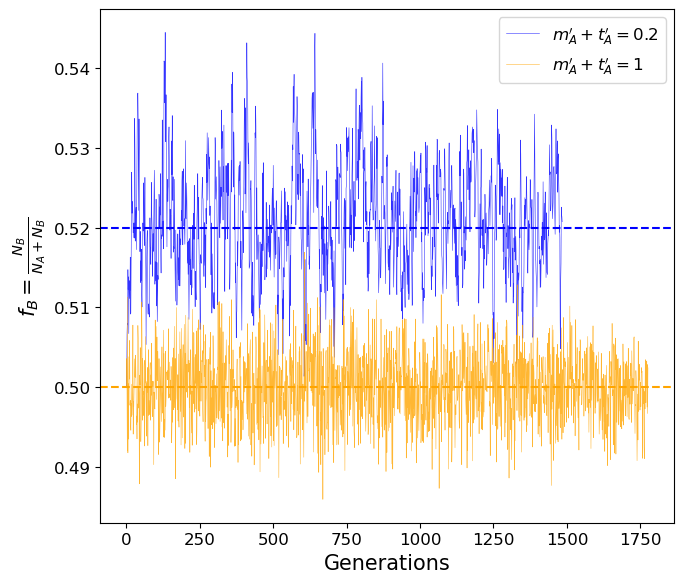

In [495]:

#wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre 
#wAA = 0 wAB = 0.1 wBB = 0.2 wAa = 0.3 wAb = 0.4 waB = 0.5 wBb = 0.6 wbb = 0.7 wab = 0.8 waa = 1
rpost=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
#hbpost=0.625
#hBpost=0.3
mu=0
nu=0
N_start=10**4
NoR = 10**3

seed = int(np.random.random()*10000)
print(6256) #1077

#xpre_range = np.arange(0,1.1,0.2)
xpost_range = np.arange(0,1.05,0.05)

hbpost, hBpost = 0,1
hpost_list = [0,1,hBpost,1-hbpost]

a = mp.cpu_count() - 2

ExtProb = [] 
Ext_row = []

mApre = 0.8
tApre = 0.8
mapre = 0.1
tapre = 0.9

hpre_list = [0,1,hBpre,1-hbpre]
pA,pB = Haploid_PreChange(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,NoG = 10**5, timeseries = False)

plt.figure(figsize = (7,6))
colors = ['blue', 'orange', 'green']

ind = 0 
for xtot in [0.2,1]:
    print(xtot)
    xpost = 0.5 
    ymean = []
    ystd = []
    for rep in range(1):
        y = round(xpost,5)

        mApost = xtot*xpost
        tApost = (1-xpost)*xtot
        mapost = 0 
        tapost = 1 

        Ext = 1
        while Ext == 1:
            NA_list, Na_list, NB_list, Nb_list, Ext = Haploid(pA,pB,0,0,spost,rpost,hpost_list,mapost,mApost,tapost,tApost,N_start,mu,nu,timeseries = True)

    ymean += [np.mean(np.array(NB_list)/(np.array(NB_list)+np.array(NA_list)))]
    ystd += [np.std(np.array(NB_list)/(np.array(NB_list)+np.array(NA_list)))]
    plt.plot(np.array(NB_list)/(np.array(NB_list)+np.array(NA_list)) , label = "$m_A'+t_A'=$"+str(xtot), lw = 0.4, color = colors[ind], alpha = 0.8)
    plt.axhline(y= r/spost*((1/xtot-1)*(spost-r) + 1), linestyle = '--', color = colors[ind] )
    ind += 1
    plt.legend(fontsize = 12, loc = "upper right")

#plt.axhline(y= r/spost, linestyle = '--', color = 'black' )
plt.ylabel("$f_B = \\frac{N_B}{N_A+N_B}$", fontsize = 15)
plt.xlabel("Generations", fontsize = 15)
#plt.ylim((0.4,0.6))
plt.tight_layout()
plt.savefig('QEEPureEpi.png', format= 'png')


## Probability of rescue - Environment specificity only (Haploid)

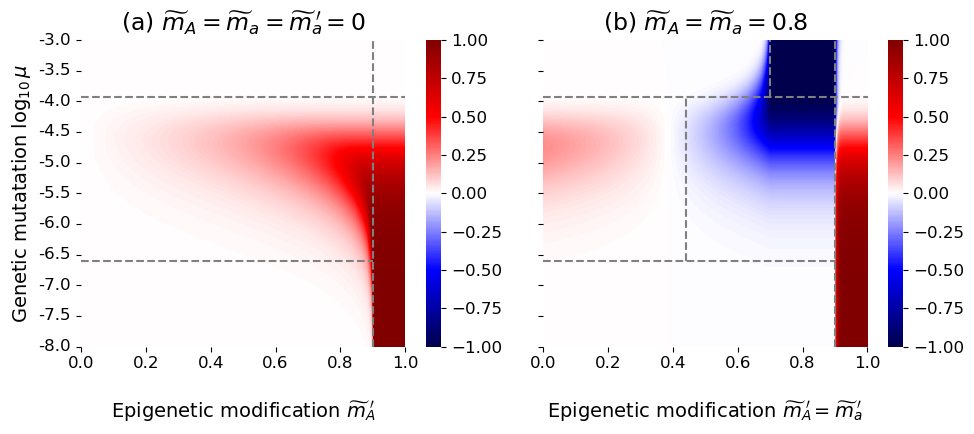

"\nPres_vals_grid = []\nfor mu in mu_rng: \n    nu = mu \n    mpre = round(mpre,5)\n    mapre = mpre\n    mApre = mpre\n    Pres_vals = []\n    for mpost in mpost_range: \n        Pres_onlygen = 1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) )\n\n        mpost = round(mpost,5)\n        mApost = mpost\n        mapost = mpost\n        Presval = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0]\n        Pres_vals += [ Pres_onlygen ]\n    Pres_vals_grid += [Pres_vals]\nPres_df = pd.DataFrame(Pres_vals_grid[::-1], index = np.round(np.log10(mu_rng),4)[::-1], columns = np.round(mpost_range,4))\n\nTgenetic = (1-r/spost)/hbpost\nTepi = (r/spost)/hBpost\n\nimport seaborn \n\nax = seaborn.heatmap(Pres_df, center = 0, cmap = 'coolwarm')\n"

In [10]:
import pandas as pd 
import seaborn 
from numpy import interp
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
N=10**4
hbpost, hBpost = (1-r/spost)/0.7,(r/spost)/0.9
mpre_range = np.arange(0,1.05,0.05)
mu_rng = [10**x for x in np.arange(-8,-2.995,0.005)]
mpost_range = np.arange(0,1.001,0.001)
    
def generate_df(mapre = 0, mApreval = 'same',mapostval = 'same'): 

    r=0.01
    spre=0.01
    spost=0.02
    hbpre=0.8
    hBpre=0.1
    N=10**4

    #mu=10**(-6)
    #nu=10**(-6)


    mpre_range = np.arange(0,1.05,0.05)

    mu_rng = [10**x for x in np.arange(-8,-2.995,0.005)]

    mpost_range = np.arange(0,1.001,0.001)

    %matplotlib inline

    cmap = mpl.colormaps['winter']

    #fig, ax = plt.subplots(1,1)


    hbpost, hBpost = (1-r/spost)/0.7,(r/spost)/0.9

    #hBpost = 1 


    Pres_vals_grid = []
    for mu in mu_rng: 
        nu = mu 
        mApre = mapre if mApreval == 'same' else mApreval
        Pres_vals = []
        for mpost in mpost_range: 
            Pres_onlygen = 1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) )

            mpost = round(mpost,5)
            mApost = mpost
            mapost = mpost if mapostval == 'same' else mapostval
            Presval = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0]
            Pres_vals += [ Presval - Pres_onlygen ]
        Pres_vals_grid += [Pres_vals]

    mu_rng_log10 = np.round(np.log10(mu_rng),4)[::-1]
    Pres_df = pd.DataFrame(Pres_vals_grid[::-1], index = mu_rng_log10, columns = np.round(mpost_range,4))
    return Pres_df

%matplotlib inline 
fig, ax = plt.subplots(1,2, figsize = (10,4.5))

mapre = 0.7

Tepi = (r/spost)/hBpost
Tgenetic = (1-r/spost)*(mapre*hbpre+mapre*hBpre)/hbpost
Tgenetic2 = (1-r/spost)/hbpost

Tepi_x = interp(Tepi,mpost_range, np.arange(len(mpost_range)))
Tgenetic_x = interp(Tgenetic,mpost_range, np.arange(len(mpost_range)))
Tgenetic2_x = interp(Tgenetic2,mpost_range, np.arange(len(mpost_range)))

T1_y = interp(np.log10(-np.log(0.99)/(2*(spost-r)*(1/spre+1/r)*N)),np.round(np.log10(mu_rng),4), np.arange(len(np.round(np.log10(mu_rng),4))))
T1_y = len(np.round(np.log10(mu_rng),4)) - T1_y -1
T99_y = interp(np.log10(-np.log(0.01)/(2*(spost-r)*(1/spre+1/r)*N)),np.round(np.log10(mu_rng),4), np.arange(len(np.round(np.log10(mu_rng),4))))
T99_y = len(np.round(np.log10(mu_rng),4)) - T99_y -1

Pres_df = generate_df(mapre = mapre, mApreval = 'same',mapostval = 'same')
ax1 = seaborn.heatmap(Pres_df, center = 0, vmin= -1, vmax=1, cmap = 'seismic', ax = ax[1], xticklabels=200, yticklabels=100)

ax1.axvline(x = Tepi_x, color = 'gray', linestyle = '--')
ax1.axvline(x = Tgenetic_x, ymin = 1-T1_y/len(mu_rng), ymax = 1-T99_y/len(mu_rng), color = 'gray', linestyle = '--')
ax1.axvline(x = Tgenetic2_x, ymin = 1-T99_y/len(mu_rng) , color = 'gray', linestyle = '--')

ax1.set_yticklabels([],rotation=0) 

ax1.axhline(y = T1_y, xmax=Tepi_x/len(mpost_range), color = 'gray', linestyle = '--')
ax1.axhline(y = T99_y, color = 'gray', linestyle = '--')

mapre = 0

Pres_df = generate_df(mapre = mapre, mApreval = 0,mapostval = 0)
ax0 = seaborn.heatmap(Pres_df, center = 0, vmin= -1, vmax=1, cmap = 'seismic', ax = ax[0], xticklabels=200, yticklabels=100)

ax0.axvline(x = Tepi_x, color = 'gray', linestyle = '--')
ax0.axhline(y = T1_y, xmax=Tepi_x/len(mpost_range), color = 'gray', linestyle = '--')
ax0.axhline(y = T99_y, color = 'gray', linestyle = '--')

ax0.set_yticklabels(ax0.get_yticklabels(),rotation=0) 


ax[0].set_ylabel(r"Genetic mutatation $\log_{10}\mu$")

ax[0].set_xlabel("\n" + r"Epigenetic modification $\widetilde{m}_A\hspace{-0.3}'$")
ax[0].set_title("(a) " + r"$\widetilde{m}_A = \widetilde{m}_a = \widetilde{m}_a\hspace{-0.3}' = 0$")


ax[1].set_xlabel("\n" + r"Epigenetic modification $\widetilde{m}_A\hspace{-0.3}' = \widetilde{m}_a\hspace{-0.3}'$")
ax[1].set_title("(b) " + r"$\widetilde{m}_A = \widetilde{m}_a = 0.8$")

#ax[0].set_xlabel(r"Epigenetic modification $\\widetilde{m}_A = \\widetilde{m}_a$")

plt.tight_layout()

plt.savefig('Plasticity.png',format='png',bbox_inches='tight')
plt.savefig('Plasticity.svg',format='svg')
plt.show()

"""
Pres_vals_grid = []
for mu in mu_rng: 
    nu = mu 
    mpre = round(mpre,5)
    mapre = mpre
    mApre = mpre
    Pres_vals = []
    for mpost in mpost_range: 
        Pres_onlygen = 1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) )

        mpost = round(mpost,5)
        mApost = mpost
        mapost = mpost
        Presval = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0]
        Pres_vals += [ Pres_onlygen ]
    Pres_vals_grid += [Pres_vals]
Pres_df = pd.DataFrame(Pres_vals_grid[::-1], index = np.round(np.log10(mu_rng),4)[::-1], columns = np.round(mpost_range,4))

Tgenetic = (1-r/spost)/hbpost
Tepi = (r/spost)/hBpost

import seaborn 

ax = seaborn.heatmap(Pres_df, center = 0, cmap = 'coolwarm')
"""



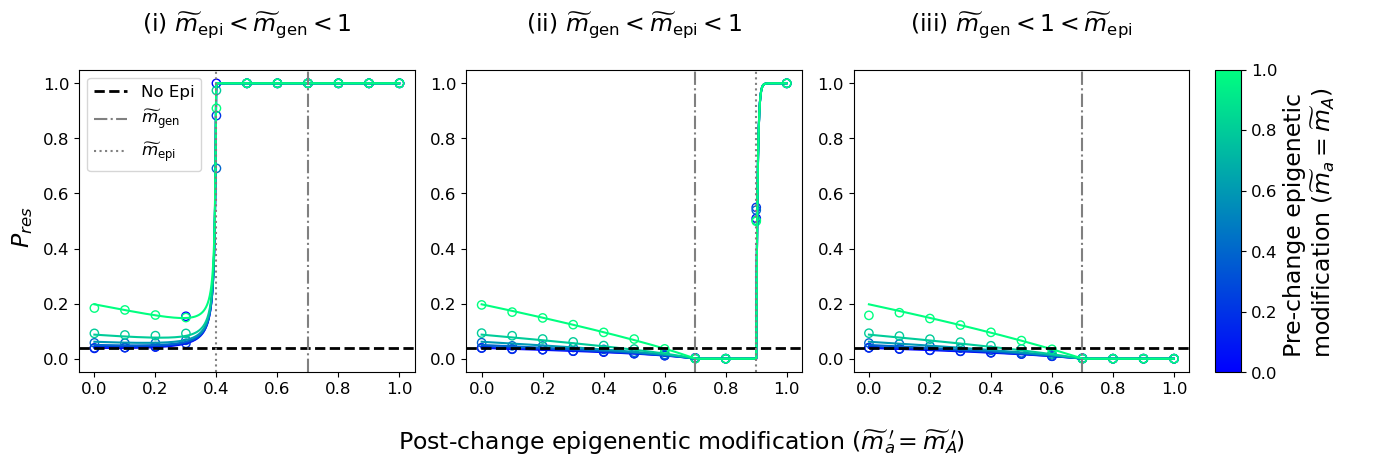

In [41]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4


mpre_range = np.arange(0,1.05,0.2)
mpost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 7, gridspec_kw={'wspace':0.0, 'width_ratios': [13,2,13,2,13,1,1]}, figsize=(14,4.7))

hpost_vals = [[(1-r/spost)/0.7,(r/spost)/0.4],[(1-r/spost)/0.7,(r/spost)/0.9],[(1-r/spost)/0.7,(r/spost)/1.1]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    
    axcur = ax[2*ind]
    ax[2*ind+1].set_visible(False)
    axcur.set_ylim([-0.05, 1.05])
    for mpre in mpre_range:
        if mpre in [0.0,0.2,0.4,0.6,0.8,1.0]:
            HaploidERwriter = pd.ExcelFile('./DataFiles/Haploid_ER'+str(ind)+'_'+str(mpre)+'.xlsx')
            HaploidDF = pd.read_excel(HaploidERwriter, sheet_name = str(mpre) ,index_col=0)
            HaploidDF = HaploidDF.transpose()
            axcur.scatter(np.arange(0,1.1,0.1),1-np.array(HaploidDF[mpre]), edgecolor = cmap(mpre), color = 'none')
            
            
        mpre = round(mpre,5)
        mapre = mpre
        mApre = mpre
        Pres_vals = []
        for mpost in mpost_range: 
            mpost = round(mpost,5)
            mApost = mpost
            mapost = mpost
            Presval = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0]
            Pres_vals += [ Presval ]
            
        axcur.plot(mpost_range, Pres_vals, color = cmap(mpre))
        
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    
    if 0<Tgenetic < 1 : 
        axcur.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    if 0<Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')
    
    
ax[0].set_title(r'(i) $\widetilde{m}_\text{epi} < \widetilde{m}_\text{gen} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'(ii) $\widetilde{m}_\text{gen} < \widetilde{m}_\text{epi} < 1$' + '\n', fontsize = 17)
ax[4].set_title(r'(iii) $\widetilde{m}_\text{gen} < 1 < \widetilde{m}_\text{epi}$' + '\n', fontsize = 17)


fig.supxlabel('Post-change epigenentic modification '+r"$(\widetilde{m}_{a}\hspace{-0.3}' = \widetilde{m}_{A}\hspace{-0.3}')$", fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 17)
ax[0].legend()

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Pre-change epigenetic \nmodification '+r'($\widetilde{m}_{a}=\widetilde{m}_{A}$)' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("AlleleIndependent.svg",format="svg")
plt.savefig("AlleleIndependent.png",format="png")
plt.show()



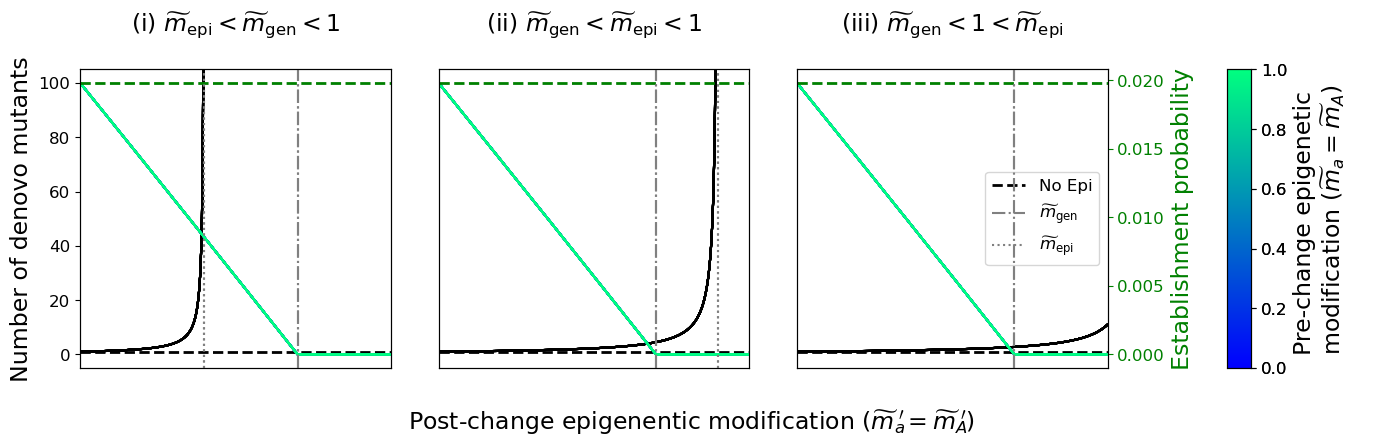

In [40]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4


mpre_range = np.arange(0,1.05,0.05)
mpost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 7, gridspec_kw={'wspace':0.0, 'width_ratios': [13,2,13,2,13,5,1]}, figsize=(14,4.5), sharex = True, sharey= False)
axtw = [ax_ind.twinx() for ax_ind in ax]

hpost_vals = [[(1-r/spost)/0.7,(r/spost)/0.4],[(1-r/spost)/0.7,(r/spost)/0.9],[(1-r/spost)/0.7,(r/spost)/1.1]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    axdenovo = ax[2*ind]
    axpest = axtw[2*ind]
    cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
    ax[2*ind+1].set_visible(False)
    ax[2*ind+1].set_visible(False)
    axtw[2*ind+1].set_visible(False)
    axtw[2*ind+1].set_visible(False)
    
    
    axdenovo.set_ylim([-5, 105])
    axdenovo.set_xlim([-0.05, 1.05])
    #axpest.set_ylim([-0.05, 1.05])
    
    for mpre in mpre_range:
        mpre = round(mpre,5)
        mapre = mpre
        mApre = mpre
        Ndenovo_vals = []
        pest_vals = [] 
        for mpost in mpost_range: 
            mpost = round(mpost,5)
            mApost = mpost
            mapost = mpost
            Presval, Ndenovo, pest = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
            Ndenovo_vals += [ Ndenovo ]
            pest_vals += [ pest ]
            
        axdenovo.plot(mpost_range, Ndenovo_vals, color = 'black')
        axpest.plot(mpost_range, pest_vals, color = cmap(mpre))
        
    axdenovo.axhline(y=mu/r*N*(1-mu/spre), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    axpest.axhline(y=1-np.exp(-2*(spost-r)), linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )
    
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    
    axdenovo.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    axpest.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    
    axdenovo.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')
    axpest.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')

    if ind != 0:
        axdenovo.axes.get_yaxis().set_visible(False) 
    if ind != 2:
        axpest.axes.get_yaxis().set_visible(False)



ax[0].set_title(r'(i) $\widetilde{m}_\text{epi} < \widetilde{m}_\text{gen} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'(ii) $\widetilde{m}_\text{gen} < \widetilde{m}_\text{epi} < 1$' + '\n', fontsize = 17)
ax[4].set_title(r'(iii) $\widetilde{m}_\text{gen} < 1 < \widetilde{m}_\text{epi}$' + '\n', fontsize = 17)

ax[0].set_ylabel('Number of denovo mutants', fontsize=17)
axtw[4].set_ylabel('Establishment probability', fontsize=17, color = 'green')
axtw[4].tick_params(colors="green", axis = "y")
cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
#ax[0].set_ylabel('Establishment prob', fontsize=17)
fig.supxlabel('Post-change epigenentic modification '+r"$(\widetilde{m}_{a}\hspace{-0.3}' = \widetilde{m}_{A}\hspace{-0.3}')$", fontsize = 17)
ax[4].legend(loc='center right')

#cb = mpl.colorbar.ColorbarBase([-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Pre-change epigenetic \nmodification '+r'($\widetilde{m}_{a}=\widetilde{m}_{A}$)' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("AlleleIndependentComponents.svg",format="svg")
plt.savefig("AlleleIndependentComponents.png",format="png")
plt.show()


## Probability of rescue - Allele specificity only (Haploid)

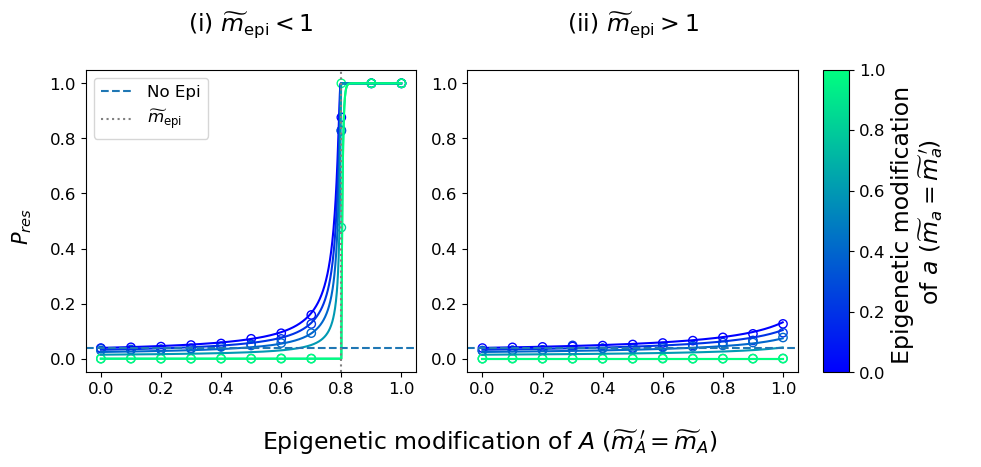

In [39]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4


ma_range = np.arange(0,1.2,0.2)
mA_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 5, gridspec_kw={'wspace':0,'width_ratios': [13,2,13,1,1]}, figsize=(10,4.7))

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.8],[(1-r/spost)/0.8,(r/spost)/1.2]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    Tgen = (1-r/spost)/hbpost
    
    axcur = ax[ind*2]
    ax[ind*2+1].set_visible(False)
    
    axcur.set_ylim([-0.05, 1.05])
    for ma in ma_range:
        
        if ma in [0.0,0.2,0.4,0.6,0.8,1.0]:
            HaploidERwriter = pd.ExcelFile('./DataFiles/Haploid_ER'+str(ind+3)+'_'+str(ma)+'.xlsx')
            HaploidDF = pd.read_excel(HaploidERwriter, sheet_name = str(ma) ,index_col=0)
            HaploidDF = HaploidDF.transpose()
            axcur.scatter(np.arange(0,1.1,0.1),1-np.array(HaploidDF[ma]), edgecolor = cmap(ma), color = 'none')
            
        
        
        ma = round(ma,5)
        mapre = ma
        mapost = ma
        Pres_vals = []
        for mA in mA_range: 
            mA = round(mA,5)
            mApre = mA
            mApost = mA
            Pres_vals += [ Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0] ]
        axcur.plot(mA_range, Pres_vals, color = cmap(ma))
        
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi" )
    Tepi = (r/spost)/hBpost
    if Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel("Epigenetic modification \nof $a$ ($\widetilde{m}_{a}=\widetilde{m}_{a}\hspace{-0.3}')$" +' \n', fontsize = 17)

ax[0].set_title(r'(i) $\widetilde{m}_\text{epi} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'(ii) $\widetilde{m}_\text{epi} > 1$' + '\n', fontsize = 17)

fig.supxlabel(r"Epigenetic modification of $A$ $(\widetilde{m}_{A}\hspace{-0.3}' = \widetilde{m}_{A})$", fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 15)
ax[0].legend()

plt.tight_layout()
plt.savefig("EnvironmentIndependent.svg",format="svg")
plt.savefig("EnvironmentIndependent.png",format="png")
plt.show()


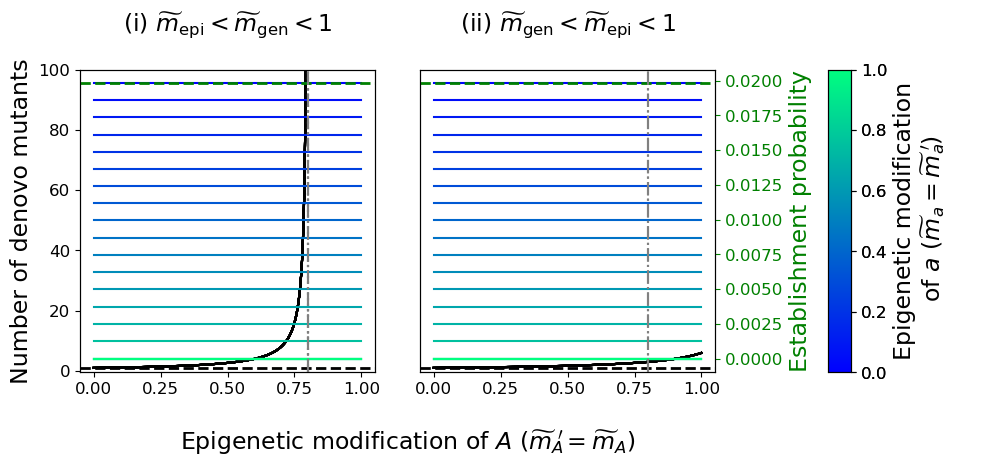

In [38]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4


ma_range = np.arange(0,1.05,0.05)
mA_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']
fig, ax = plt.subplots(1, 5, gridspec_kw={'wspace':0,'width_ratios': [13,2,13,5,1]}, figsize=(10,4.7))

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.8],[(1-r/spost)/0.8,(r/spost)/1.2]]

axtw = [ax_ind.twinx() for ax_ind in ax]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    axdenovo = ax[2*ind]
    axpest = axtw[2*ind]
    
    ax[2*ind+1].set_visible(False)
    ax[2*ind+1].set_visible(False)
    axtw[2*ind+1].set_visible(False)
    axtw[2*ind+1].set_visible(False)
    
    
    axdenovo.set_ylim([-0.5, 100])
    axdenovo.set_xlim([-0.05, 1.05])
    #axpest.set_ylim([-0.05, 1.05])
    
    for ma in ma_range:
        ma = round(ma,5)
        mapre = ma
        mapost = ma
        Ndenovo_vals = []
        pest_vals = [] 
        for mA in mA_range: 
            mA = round(mA,5)
            mApost = mA
            mApre = mA
            Presval, Ndenovo, pest = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
            Ndenovo_vals += [ Ndenovo ]
            pest_vals += [ pest ]
            
        axdenovo.plot(mA_range, Ndenovo_vals, color = 'black')
        axpest.plot(mA_range, pest_vals, color = cmap(ma))
        
    axdenovo.axhline(y=mu/r*N*(1-mu/spre), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    axpest.axhline(y=1-np.exp(-2*(spost-r)), linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )
    
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    
    axdenovo.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    axpest.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    
    axdenovo.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')
    axpest.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')

    if ind != 0:
        axdenovo.axes.get_yaxis().set_visible(False) 
    if ind != 1:
        axpest.axes.get_yaxis().set_visible(False)



ax[0].set_title(r'(i) $\widetilde{m}_\text{epi} < \widetilde{m}_\text{gen} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'(ii) $\widetilde{m}_\text{gen} < \widetilde{m}_\text{epi} < 1$' + '\n', fontsize = 17)
#ax[4].set_title(r'(iii) $\widetilde{m}_{gen} < 1 < \widetilde{m}_{epi}$' + '\n', fontsize = 17)

ax[0].set_ylabel('Number of denovo mutants', fontsize=17)
axtw[2].tick_params(colors="green", axis = "y")
axtw[2].set_ylabel('Establishment probability', fontsize=17, color = 'green')

#axtw[4].tick_params(colors="red", axis = "y")

#ax[0].set_ylabel('Establishment prob', fontsize=17)

fig.supxlabel(r"$\hspace{-27}$Epigenetic modification of $A$ $(\widetilde{m}_{A}\hspace{-0.3}' = \widetilde{m}_{A})$", fontsize = 17)
#ax[4].legend(loc='center right')

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Epigenetic modification\n of $a$ '+r"($\widetilde{m}_{a}=\widetilde{m}_{a}\hspace{-0.3}'$)" +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("EnvironmentIndependentComponents.svg",format="svg")
plt.savefig("EnvironmentIndependentComponents.png",format="png")
plt.show()

## Environment and allele specificity - Haploid

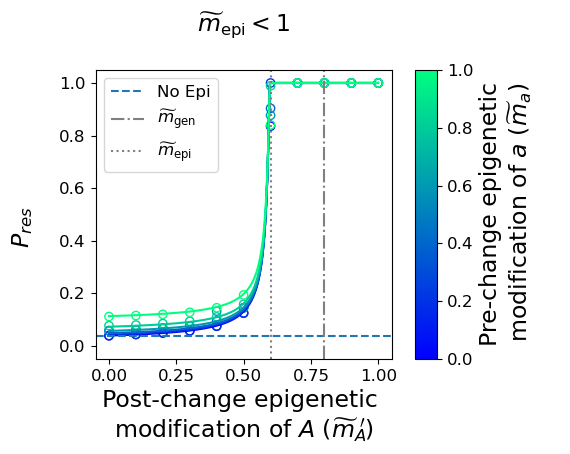

In [36]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4
mapost = 0
mApre = 0

mapre_range = np.arange(0,1.01,0.2)
mApost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 3, gridspec_kw={'wspace':0,'width_ratios': [13,1,1]}, figsize=(5.8,4.7))

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.6]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    Tepi = (r/spost)/hBpost
    
    axcur = ax[ind*2]
    ax[ind*2+1].set_visible(False)
    
    axcur.set_ylim([-0.05, 1.05])
    for mapre in mapre_range:
        mapre = round(mapre,5)
        
        if mapre in [0.0,0.2,0.4,0.6,0.8,1.0]:
            HaploidERwriter = pd.ExcelFile('./DataFiles/Haploid_ER'+str(ind+5)+'_'+str(mapre)+'.xlsx')
            HaploidDF = pd.read_excel(HaploidERwriter, sheet_name = str(mapre) ,index_col=0)
            HaploidDF = HaploidDF.transpose()
            axcur.scatter(np.arange(0,1.1,0.1),1-np.array(HaploidDF[mapre]), edgecolor = cmap(mapre), color = 'none')
            
        Pres_vals = []
        for mApost in mApost_range: 
            mApost = round(mApost,5)
            Pres_vals += [ Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)[0] ]
        axcur.plot(mApost_range, Pres_vals, color = cmap(mapre))
        
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi" )
    Tgenetic = (1-r/spost)/hbpost if hbpost !=0 else 2
    Tepi = (r/spost)/hBpost
    

    if Tgenetic < 1 : 
        axcur.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_\text{gen}$')
    if Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_\text{epi}$')

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Pre-change epigenetic\n modification of $a$ $(\widetilde{m}_{a})$' +' \n', fontsize = 17)

ax[0].set_title(r'$\widetilde{m}_\text{epi} < 1$' + '\n', fontsize = 17)

ax[0].set_xlabel("Post-change epigenetic \nmodification of $A$ $(\widetilde{m}_{A}\hspace{-0.3}')$", fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 17)
ax[0].legend()

ax[-2].set_ylabel(r'$\widetilde{m}_{a,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("IdealCase.svg",format="svg")
plt.savefig("IdealCase.png",format="png")
plt.show()

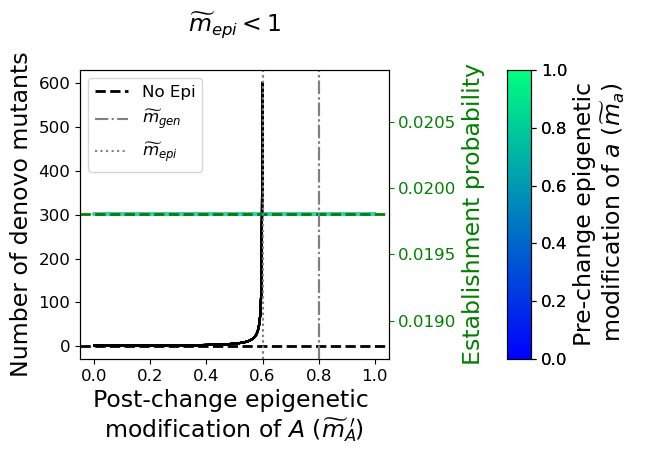

In [12]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.7
mu=10**(-6)
nu=10**(-6)
N=10**4
mapost = 0
mApre = 0

mapre_range = np.arange(0,1,0.05)
mApost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 3, gridspec_kw={'wspace':0,'width_ratios': [13,5,1]}, figsize=(6.8,4.7))
axtw = [ax_ind.twinx() for ax_ind in ax]

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.6]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    Tepi = (r/spost)/hBpost
    
    axdenovo = ax[2*ind]
    axpest = axtw[2*ind]
    
    ax[ind*2+1].set_visible(False)
    axtw[ind*2+1].set_visible(False)
    
    
    for mapre in mapre_range:
        mapre = round(mapre,5)
        Ndenovo_vals = []
        Pest_vals = []
        for mApost in mApost_range: 
            mApost = round(mApost,5)
            Pres, Ndenovo, Pest = Pres_haploid(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
            Ndenovo_vals += [Ndenovo]
            Pest_vals += [Pest] 
            
            
        axpest.plot(mApost_range, Pest_vals, color = cmap(mapre))
        axdenovo.plot(mApost_range, Ndenovo_vals, color = 'black')
        
    axdenovo.axhline(y=mu/r*N*(1-mu/spre), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    axpest.axhline(y=1-np.exp(-2*(spost-r)), linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )
    
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    
    axdenovo.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_{gen}$')
    axpest.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_{gen}$')
    
    axdenovo.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_{epi}$')
    axpest.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_{epi}$')

    if ind != 0:
        axdenovo.axes.get_yaxis().set_visible(False) 
    if ind != 0:
        axpest.axes.get_yaxis().set_visible(False)

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Pre-change epigenetic\n modification of $a$ $(\widetilde{m}_{a})$' +' \n', fontsize = 17)

ax[0].set_ylabel('Number of denovo mutants', fontsize=17)
axtw[0].tick_params(colors="green", axis = "y")
axtw[0].set_ylabel('Establishment probability', fontsize=17, color = 'green')

ax[0].set_title(r'$\widetilde{m}_{epi} < 1$' + '\n', fontsize = 17)

ax[0].set_xlabel("Post-change epigenetic \nmodification of $A$ $(\widetilde{m}_{A}\hspace{-0.3}')$", fontsize = 17)
ax[0].legend()

ax[-2].set_ylabel(r'$\widetilde{m}_{a,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("IdealCaseComponents.svg",format="svg")
plt.savefig("IdealCaseComponents.png",format="png")
plt.show()

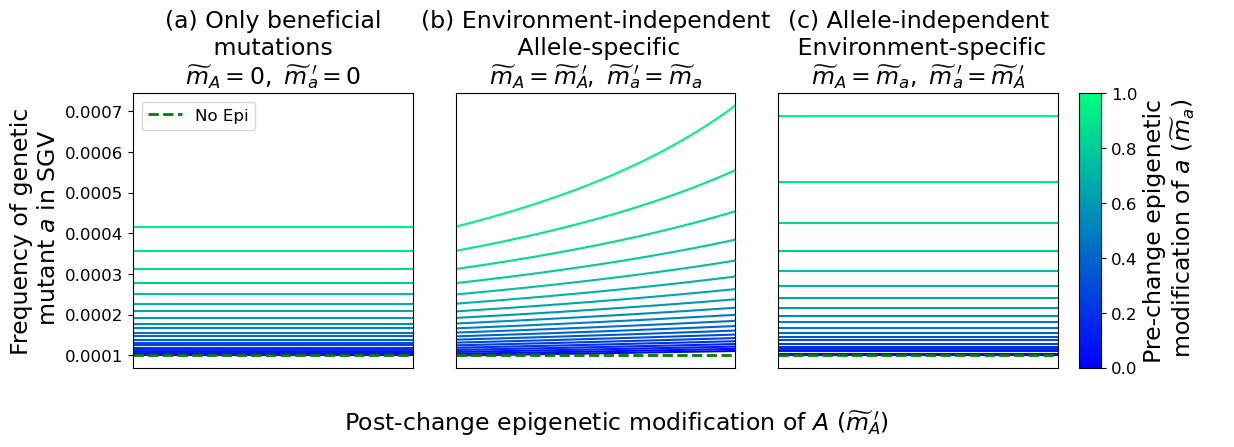

In [47]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
mu=10**(-6)
nu=10**(-6)
N=10**4
mapost = 0
mApre = 0

mapre_range = np.arange(0,1,0.05)
mApost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 7, gridspec_kw={'wspace':0.0, 'width_ratios': [13,2,13,2,13,1,1]}, figsize=(12.5,4.5), sharex = True, sharey= False)
ax[1].set_visible(False)
ax[3].set_visible(False)
ax[5].set_visible(False)

for mapre in mapre_range:
    pasgv1 = []
    pasgv2 = []
    pasgv3 = []
    for mApost in mApost_range: 
        pasgv1 += [mu/((1-(mapre*hbpre))*spre)]
        pasgv2 += [mu/((1-(mapre*hbpre+mApost*hBpre))*spre)]
        pasgv3 += [mu/((1-(mapre*hbpre+mapre*hBpre))*spre)]
    
    ax[0].plot(mApost_range,pasgv1, color = cmap(mapre))
    ax[2].plot(mApost_range,pasgv2, color = cmap(mapre))
    ax[4].plot(mApost_range,pasgv3, color = cmap(mapre))

ax[0].sharey(ax[2])
ax[4].sharey(ax[2])

ax[0].set_title('(a) Only beneficial\n mutations \n' + "$\widetilde{m}_A = 0, \ \widetilde{m}_a\hspace{-0.3}' = 0$" , fontsize = 17)
ax[2].set_title('(b) Environment-independent\n Allele-specific\n'+ "$\widetilde{m}_A = \widetilde{m}_A\hspace{-0.3}',\ \widetilde{m}_a\hspace{-0.3}' = \widetilde{m}_a$", fontsize = 17)
ax[4].set_title('(c) Allele-independent\n Environment-specific\n'+ "$\widetilde{m}_A = \widetilde{m}_a,\ \widetilde{m}_a\hspace{-0.3}' = \widetilde{m}_A\hspace{-0.3}'$", fontsize = 17)

ax[2].axes.get_yaxis().set_visible(False) 
ax[4].axes.get_yaxis().set_visible(False) 

ax[0].axhline(y=mu/spre, linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )
ax[2].axhline(y=mu/spre, linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )
ax[4].axhline(y=mu/spre, linestyle = "--", label = "No Epi", color = 'green', linewidth =2 )

fig.supxlabel(r"$\hspace{-20}$Post-change epigenetic modification of $A$ $(\widetilde{m}_{A}\hspace{-0.3}')$", fontsize = 17)

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel('Pre-change epigenetic\n modification of $a$ $(\widetilde{m}_{a})$' +' \n', fontsize = 17)
ax[0].set_ylabel('Frequency of genetic\n mutant $a$ in SGV', fontsize = 17)
ax[0].legend(loc='upper left')
plt.tight_layout()

plt.savefig("SGV_rescue.svg",format="svg")
plt.savefig("SGV_rescue.png",format="png")


plt.show()

# Diploid Model - Epimutation

In [5]:
def prechange_diploid_det(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre 
    
    pA = 1
    pB = 0 
    pa = 0
    pb = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = (wAA*pA+wAa*pa+wAB*pB+wAb*pb)*pA
        pas = (wAa*pA+waa*pa+waB*pB+wab*pb)*pa
        pBs = (wAB*pA+waB*pa+wBB*pB+wBb*pb)*pB
        pbs = (wAb*pA+wab*pa+wBb*pB+wbb*pb)*pb
        
        pAmut = (1-mApre)*(1-mu)*pAs + tApre*(1-nu)*pBs + mu*pas 
        pamut = (1-mapre)*(1-mu)*pas + tapre*(1-nu)*pbs + mu*pAs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pAs + nu*pbs
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pas + nu*pBs
        
        wavg = pAmut + pamut + pBmut + pbmut    
        
        pAnext = pAmut/wavg
        pBnext = pBmut/wavg
        panext = pamut/wavg
        pbnext = 1-(pAnext+pBnext+panext)
        
        if pAnext + pBnext + panext + pbnext > 1:
            print("Negatives imminent", pAnext + pBnext + panext, pbnext)     
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pB = pBnext 
        pa = panext 
        pb = pbnext 
        
        if pA < 0 or pB < 0 or pa <0 or pb <0 : 
            raise TypeError("Negativesss", [pAlist[-1], pAs, pAmut, pA], [pBlist[-1], pBs, pBmut, pB], [palist[-1], pas, pamut, pa], [pblist[-1], pbs, pbmut, pb])
        
        if timeseries: 
            pAlist += [pA]
            pBlist += [pB]
            palist += [pa]
            pblist += [pb]
            
    if timeseries: 
        return [pAlist, palist, pBlist, pblist, pA, pa, pB, pb]
    
    return [pAnext,panext,pBnext,pbnext]

def prechange_diploid_analytic(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu): 
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    fA = tApre/(mApre + tApre)
    fB = 1-fA
    fa = tapre/(mapre + tapre)
    fb = 1-fa
    
    mueff = fA*mu + fB*nu
    nueff = fa*mu + fb*nu
    wAAeff = fA**2*wAA + 2*fA*fB*wAB + fB**2*wBB
    waaeff = fa**2*waa + 2*fa*fb*wab + fb**2*wbb
    wAaeff = fA*fa*wAa + fB*fb*wBb + fB*fa*waB + fA*fb*wAb 
    
    sAAeff = wAAeff - 1
    saaeff = waaeff - 1 
    sAaeff = wAaeff - 1 
    
    seff = (wAAeff - waaeff)/wAAeff
    sheff = (wAAeff - wAaeff)/(wAAeff)
    heff = sheff/seff
    if wAAeff > wAaeff : 
        #print('1')
        pa_equi = mueff/(wAAeff - wAaeff) + mueff*(wAA-1)/(wAA-wAa) + mueff**2*(waa+wAA-2*wAa)/(wAA-wAa)**3 - mueff*nueff/(wAA-wAa)**2
    elif wAAeff == wAaeff > waaeff: 
        #print('2')
        pa_equi = np.sqrt(mueff/(wAAeff - waaeff))
    elif wAAeff < wAaeff < waaeff : 
        #print('3')
        pa_equi = 1 - mu/(waaeff - wAaeff)
    elif wAAeff < wAaeff == waaeff: 
        #print('4')
        pa_equi = 1 - np.sqrt(mu/(waaeff - wAAeff))
    elif wAAeff < wAaeff > waaeff: 
        #print('5')
        pa_equi = (wAAeff - wAaeff) / (wAAeff + waaeff - 2*wAaeff) + mueff/(wAaeff-wAAeff) + mu/(waaeff-wAaeff)
    else: 
        #print('6')
        pa_equi = mueff/(mueff + mu)
        
    """
    if sAAeff - sAaeff > 0:
        #print("Case I: hs > 0")
        mueff = mu*tApre/(mApre+tApre) + nu*mApre/(mApre+tApre)
        pa_equi = mueff/(sAAeff-sAaeff) #- ((1 - heff)*mu**2)/(heff**3*seff**2)
    elif saaeff - sAaeff > 0:
        #print("Case II: hs < 0 and 0 < h < 1")
        mueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        pa_equi = 1 - mueff/(saaeff - sAaeff) #+ ((heff)*mu**2)/((1-heff)**3*seff**2)
    elif (sAaeff-saaeff)*(sAaeff-sAAeff)/(saaeff+sAAeff-2*sAaeff): 
        #print("Case III: hs < 0 and (h < 0 or h > 1)")
        #mueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        #pa_equi = 1 - mueff/((1-heff)*seff) + ((heff)*mu**2)/((1-heff)**3*seff**2)
        mueff = mu*tApre/(mApre+tApre) + nu*mApre/(mApre+tApre)
        nueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        pa_equi = (sAAeff-sAaeff)/(sAAeff + saaeff - 2*sAaeff) + mueff/(sAaeff-sAAeff) + nueff/(saaeff-sAaeff) # + ( (saaeff*sAAeff-sAaeff)/(saaeff+sAAeff-2*sAaeff) +mueff/(sAaeff-sAAeff)**2 + nueff/(saaeff-sAaeff)**2 )*(mueff/(sAaeff-sAAeff)+nueff/(saaeff-sAaeff)) # sheff/(2*sheff-seff) #+ mueff/((-1 + heff)*heff*seff)-((heff*mueff)/((-1+heff)*(-1+2*heff))) + ((1+6*(-1+heff)*heff+8*(-1+heff)**2*heff**2)*mueff**2)/((-1+heff)**3*heff**3*(-1+2*heff)*seff**2)
        
        #pa_equi = 1 - pa_equi
    else:
        raise TypeError("Case IV")
    """    
    return wAAeff, waaeff, wAaeff, seff, heff, pa_equi

print("Done")

Done


In [9]:
seed = int(np.random.random()*10000) #1361, 8973- All dominance cases plus breakdown of QEE, 298
np.random.seed(1361)
print(seed)
%matplotlib inline

x_range = np.arange(0,1.01,0.02) 
#hpre_list = [0,1,0.8,0.2,0.5,0.4,0.1,0.9,0.6,0.5]
hpre_list = [0,1] + [np.random.random() for i in range(8)]
hpre_list = [0.0, 1.0, 0.62992, 0.31896, 0.71998, 0.74467, 0.01099, 0.15646, 0.97646, 0.95991]
spre = 0.01
mu = 10**(-6)
nu = 10**(-6)
NoG = 10**5

paeff_theory_list = []
paeff_re_theory_list = []
paeff_sim_list = []
pawf_list = []
pawf_freq_list = []

wAAeff_list = []
wAaeff_list = [] 
waaeff_list = [] 

slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
for x in x_range: 
    x = round(x,4)
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    mueff = mApre/(mApre+tApre)*nu + tApre/(mApre+tApre)*mu
    nueff = mapre/(mapre+tapre)*nu + tapre/(mapre+tapre)*mu
           
    wAAeff, waaeff, wAaeff, seff, heff, paeff_theory = prechange_diploid_analytic(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu)
    pAlist, palist, pBlist, pblist, pA, pa, pB, pb = prechange_diploid_det(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,timeseries=True, NoG=NoG)
    
    paeff_sim = pa + pb
    
    #print(mApre,tApre,mapre,tapre, paeff_theory)
    
    paeff_theory_list += [paeff_theory]
    
    paeff_sim_list += [paeff_sim]
    wAAeff_list += [wAAeff]
    wAaeff_list += [wAaeff]
    waaeff_list += [waaeff]
    
    slist += [ max( -np.log(mApre+tApre)/np.log(10),-np.log(mapre+tapre)/np.log(10),1)*40 ]

8314


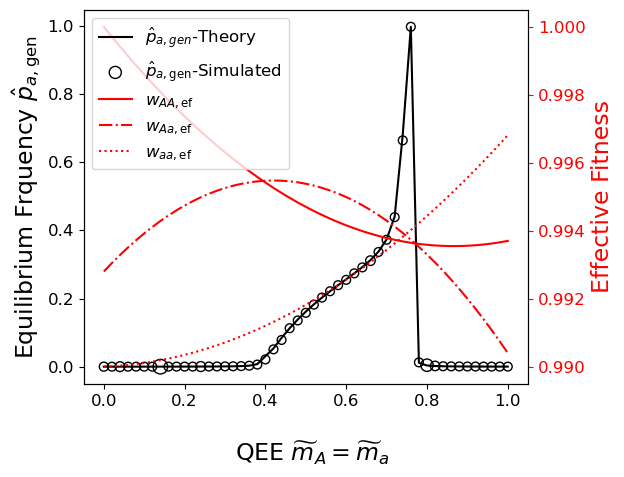

wAA = 1.0
waa = 0.99
wBB = 0.9937
wbb = 0.9968
wAa = 0.9928
wAB = 0.9926
wAb = 0.9999
waB = 0.9984
wab = 0.9902
wBb = 0.9904


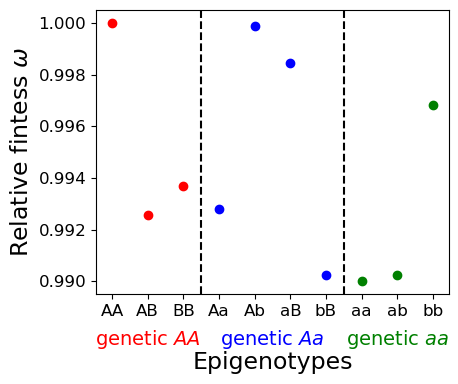

In [23]:
from matplotlib.path import Path
import matplotlib.patches as patches

%matplotlib inline

fig, ax = plt.subplots(1,1)
ax_w = ax.twinx()


ax.set_ylabel(r"Equilibrium Frquency $\hat{p}_{a,{\text{gen}}}$", color = "black", fontsize = 17)
 
ax_w.plot(x_range, wAAeff_list, label = r"$w_{AA,\text{ef}}$", color = 'red')
ax_w.plot(x_range, wAaeff_list, label = r"$w_{Aa,\text{ef}}$", color = 'red', linestyle = "-.")
ax_w.plot(x_range, waaeff_list, label = r"$w_{aa,\text{ef}}$", color = 'red', linestyle = ":")
ax_w.set_ylabel("Effective Fitness", color = "red", fontsize = 17)
ax_w.tick_params(colors="red", axis = "y")

ax.plot(x_range, paeff_theory_list, color = "black",label=r"$\hat{p}_{a,{gen}}$-Theory")
ax.scatter(x_range, paeff_sim_list, c = "none",edgecolors= "black", label=r"$\hat{p}_{a,\text{gen}}$-Simulated", s = np.array(slist)*1 )


"""
ax_h = ax.twinx()
ax_h.plot(x_range, heff_list, label = r"$h_{eff}$", color = 'grey')
ax_h.set_ylabel("Dominance Coefficient", color = "grey", fontsize = 13)
ax_h.tick_params(colors="grey", axis = "y")
ax_h.axhline(y=0, linestyle = "--", color = "grey")
"""

fig.supxlabel(r"QEE $\widetilde{m}_A = \widetilde{m}_a$", fontsize = 17)
fig.legend(loc="upper left",bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)

plt.tight_layout()
plt.savefig("DiploidEqui.png",format="png")
plt.show()
genotypes = ['wAA','waa','wBB','wbb','wAa','wAB','wAb','waB','wab','wBb']
fitness = 1-np.array(hpre_list)*spre
for geno_ind, geno in enumerate(genotypes):
    print(geno + ' = ' + str(round(fitness[geno_ind],4)))
    
wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre

fig, ax = plt.subplots(1,1,figsize = (4.75,4))

ax.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
ax.axvline(x=2.5, color = 'black',linestyle='--')
ax.scatter(['Aa','Ab','aB','bB'], [wAa,wAb,waB,wab], color = 'blue')
ax.axvline(x=6.5, color = 'black', linestyle='--')
ax.scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
ax.set_xlabel("\nEpigenotypes", fontsize = 17)
ax.set_ylabel("Relative fintess $\omega$", fontsize = 17)

ax.text(1, 0.9882, "genetic $AA$", ha='center', va='top', fontsize=14, color='red')
ax.text(4.5, 0.9882, "genetic $Aa$", ha='center', va='top', fontsize=14, color='blue')
ax.text(8, 0.9882, "genetic $aa$", ha='center', va='top', fontsize=14, color='green')


plt.tight_layout()
plt.savefig("DiploidFitness.png",format="png")

plt.show()

# Diploid - Paramutation

## Paramutable Mutant

In [70]:
def prechange_paramutableMt_det(spre,hpre_list,mapre,tapre,mu,nu,pA=1,pa=0,pb=0,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre 
    #print(wAA,waa,wbb,wAa,wAb,wab)
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        
        pAs = (wAA*pA+wAa*pa+wAb*pb)*pA
        pas = (wAa*pA+waa*pa+wab*pb)*pa
        pbs = (wAb*pA+wab*pa+wbb*pb)*pb
        
        pAmut = (1-mu)*pAs + mu*pas + nu*pbs 
        pamut = (1-mu)*pas - mapre*(1-mu)*pa*(wAa*pA+wab*pb) + tapre*(1-nu)*pbs + mu*pAs 
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pa*(wAa*pA+wab*pb)
        
        wavg = pAmut + pamut + pbmut    
        
        pAnext = pAmut/wavg
        panext = pamut/wavg
        pbnext = 1-round(pAnext+panext,5)
        
        if round(pAnext + panext + pbnext,5) > 1:
            print("Negatives imminent", pAnext + panext+ pbnext)     
        gen += 1 
        
        if gen > NoG: 
            break\left
        pA = pAnext 
        pa = panext 
        pb = pbnext 
        
        if pA < 0 or pa <0 or pb <0 : 
            raise TypeError("Negativesss", [pAs, pAmut, pA], [pas, pamut, pa], [pbs, pbmut, pb])
        
        if timeseries: 
            pAlist += [pA]
            palist += [pa]
            pblist += [pb]
            
    if timeseries: 
        return [pAlist, palist, pblist, pA, pa, pb]
    
    return [pAnext,panext,pbnext]

def prechange_paramutableMt_analytic(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre
    tatilde = tapre/(tapre+mapre)
    matilde = mapre/(tapre+mapre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    fb = matilde
    fa = 1 - fb
    
    waaeff = fa**2*waa + 2*fa*fb*wab + fb**2*wbb
    wAaeff = fa*wAa + fb*wAb 
    wAAeff = wAA
    
    
    mueff = mu
    nueff = mu*tatilde + nu*matilde
    
    if wAAeff > wAaeff : 
        #print('1')
        pa_equi = mueff/(wAAeff - wAaeff) + mueff*(wAA-1)/(wAA-wAa) + mueff**2*(waa+wAA-2*wAa)/(wAA-wAa)**3 - mueff*nueff/(wAA-wAa)**2
    elif wAAeff == wAaeff > waaeff: 
        #print('2')
        pa_equi = np.sqrt(mueff/(wAAeff - waaeff))
    elif wAAeff < wAaeff < waaeff : 
        #print('3')
        pa_equi = 1 - mu/(waaeff - wAaeff)
    elif wAAeff < wAaeff == waaeff: 
        #print('4')
        pa_equi = 1 - np.sqrt(mu/(waaeff - wAAeff))
    elif wAAeff < wAaeff > waaeff: 
        #print('5')
        pa_equi = (wAAeff - wAaeff) / (wAAeff + waaeff - 2*wAaeff) + mueff/(wAaeff-wAAeff) + mu/(waaeff-wAaeff)
    else: 
        #print('6')
        pa_equi = mueff/(mueff + mu)
    
    fa = (1 - np.sqrt(1 - 4*pa_equi*tatilde*matilde))/(2*pa_equi*matilde) if matilde !=0 else 1
    fb = 1-fa
    pa = fa*pa_equi
    pb = fb*pa_equi
    pA = 1 - pa_equi
    #print(pa_equi)
    return pa, pb


def prechange_paramutableMt_analytic_refined(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre
    tatilde = tapre/(tapre+mapre)
    matilde = mapre/(tapre+mapre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if wAb == wAA and wbb == wAA and wab == wAa: 
        s = wAA - waa 
        h = (wAA - wAa)/(wAA - waa)
        pa_genetic = mu/(wAA-wAa) if wAA-wAa != 0 else np.sqrt(mu/(wAA-waa))


        if h != 0:
            if tatilde > 0:
                pa_equi = mu/(h*s*tatilde)-(mu*(mu*(1-h)*tatilde + nu*h*matilde))/(h**3*s**2*tatilde**2)
            elif round(tatilde,4) != 0 :
                #print('1')
                A = (mu + nu)/(2*h*s*tatilde) + 1/2 
                B = mu/(h*s*tatilde)
                pa_equi = A - np.sqrt(A**2-B)
            else: 
                pa_equi = mu/(mu+nu)
        
        else: 
            if matilde < 1 - pa_genetic:
                pa_equi = (1 + mapre/tapre)*pa_genetic - (1 + mapre/tapre)**2*(mapre*nu+tapre*mu)/(2*s*(mapre+tapre))#+(-mu+(mu-nu)*matilde)*(3*mu+(mu-nu)*matilde)/(8*np.sqrt(mu)*(s*tatilde**2)**1.5)
            else: 
                pa_equi = mu/(mu+nu) - mu*tatilde*((mu-nu)*(mu+nu)**2+s*mu*nu*tatilde)/(mu+nu)**4
            if pa_equi >= 1 :
                pa_equi = 1
        
        
        
    
    fa = (1 - np.sqrt(1 - 4*pa_equi*tatilde*matilde))/(2*pa_equi*matilde) if round(matilde,4) !=0 else 1
    fb = 1-fa
    pa = fa*pa_equi
    pb = fb*pa_equi
    
    
    return pa, pb


In [71]:
%matplotlib inline
def paramutableMt_plotting(hpre_list, ax, x_range, refined=True):
    #wAA,waa,wbb,wAa,wAb,wab
    #hpre_list = [0,1] + [np.random.random() for i in range(4)]
    spre = 0.01
    mu = 10**(-4)
    nu = 10**(-4)
    NoG = 10**5

    pa_theory_list = []
    pb_theory_list = []
    
    pa_refined_theory_list = []
    pb_refined_theory_list = []
    
    pa_list = []
    pb_list = []


    slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
    for x in x_range: 
        x = round(x,4)
        #print(x)
        mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
        tapre = (1-x)*mapre/x if x != 0 else np.random.random()

        pa_theory, pb_theory = prechange_paramutableMt_analytic(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=NoG)
        
        if refined == True:
            pa_refined_theory, pb_refined_theory = prechange_paramutableMt_analytic_refined(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=NoG)
            pa_refined_theory_list += [pa_refined_theory]
            pb_refined_theory_list += [pb_refined_theory]
        
        pAlist, palist, pblist, pA, pa, pb = prechange_paramutableMt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=True, NoG=NoG)

        pa_list += [pa]
        pb_list += [pb]

        pa_theory_list += [pa_theory]
        pb_theory_list += [pb_theory]
        
    ax.scatter(x_range, pa_list, c = "none",edgecolors= "blue", label=r"$\hat{p}_{a}$-Simulated" )
    ax.scatter(x_range, pb_list, c = "none",edgecolors= "black", label=r"$\hat{p}_{b}$-Simulated" )
    ax.scatter(x_range,1 - np.array(pb_list) - np.array(pa_list), c = "none",edgecolors= "red", label=r"$\hat{p}_{a_{\text{ef}}}$-Simulated" )

    
    if refined == True: 
        ax.plot(x_range, pa_refined_theory_list, linestyle = 'solid', color = "blue",label=r"$\hat{p}_{a}$-Theory")
        ax.plot(x_range, pb_refined_theory_list, linestyle = 'solid', color = "black",label=r"$\hat{p}_{b}$-Theory")
        ax.plot(x_range, 1- np.array(pb_refined_theory_list) - np.array(pa_refined_theory_list), linestyle = 'solid', color = "red",label=r"$\hat{p}_{b}$-Theory")
    
    if refined == False:
        ax.plot(x_range, pa_theory_list, color = "blue",label=r"$\hat{p}_{a}$-Theory")
        
        ax.plot(x_range, pb_theory_list, color = "black",label=r"$\hat{p}_{b}$-Theory")
        
        ax.plot(x_range, 1 -np.array(pb_theory_list) - np.array(pa_theory_list), color = "red",label=r"$\hat{p}_{b}$-Theory")
        
    #ax.axhline(y=0, linestyle = '--')
    
    return 0 


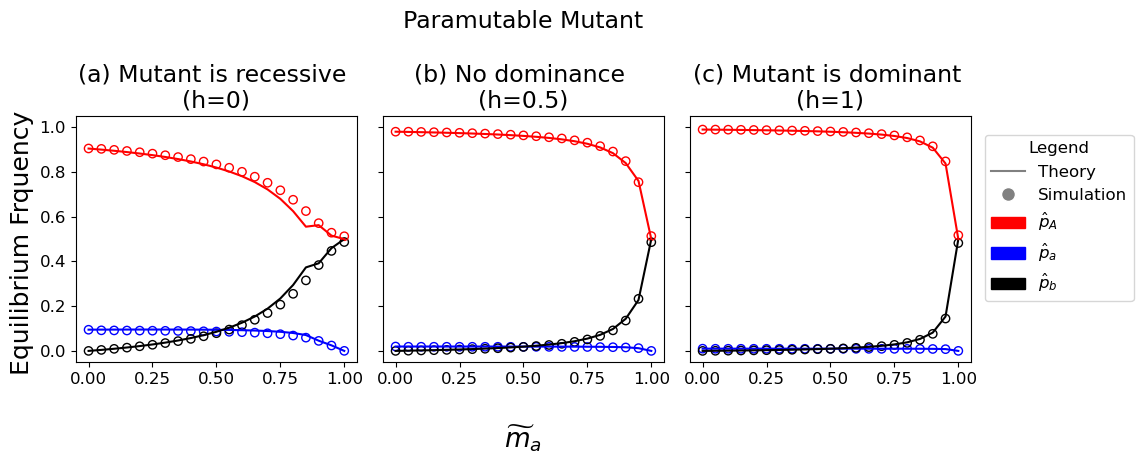

In [72]:
%matplotlib inline
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

hrng = [0,0.5,1]
xrange = np.arange(0,1.01,0.05) 
fig, ax = plt.subplots(1,3, figsize=(10,4.8), sharex = True, sharey = True)

for hind, h in enumerate(hrng): 
    hpre_list = [0,1,0,h,0,h]
    paramutableMt_plotting(hpre_list, ax[hind], xrange)

handles, labels = ax[0].get_legend_handles_labels()
custom_lines = [
    Line2D([0], [0], color='grey', label='Theory'),
    Line2D([0], [0], marker='o', color='w', label='Simulation',markerfacecolor='grey', markersize=10),
    Patch(facecolor='red', edgecolor='red',  label=r"$\hat{p}_{A}$"),
    Patch(facecolor='blue', edgecolor='blue',  label=r"$\hat{p}_{a}$"),
    Patch(facecolor='black', edgecolor='black',  label=r"$\hat{p}_{b}$")    
]


fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.15,0.72),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency ", fontsize=18)
ax[1].set_xlabel("\n"+r"$\widetilde{m}_a$", fontsize=19)
ax[1].set_title(r"Paramutable Mutant" + "\n\n(b) No dominance \n(h=0.5)")
ax[0].set_title("(a) Mutant is recessive \n(h=0)")
ax[2].set_title("(c) Mutant is dominant \n(h=1)")
plt.tight_layout()
plt.savefig('ParamutableMutant.png',format='png',bbox_inches='tight')




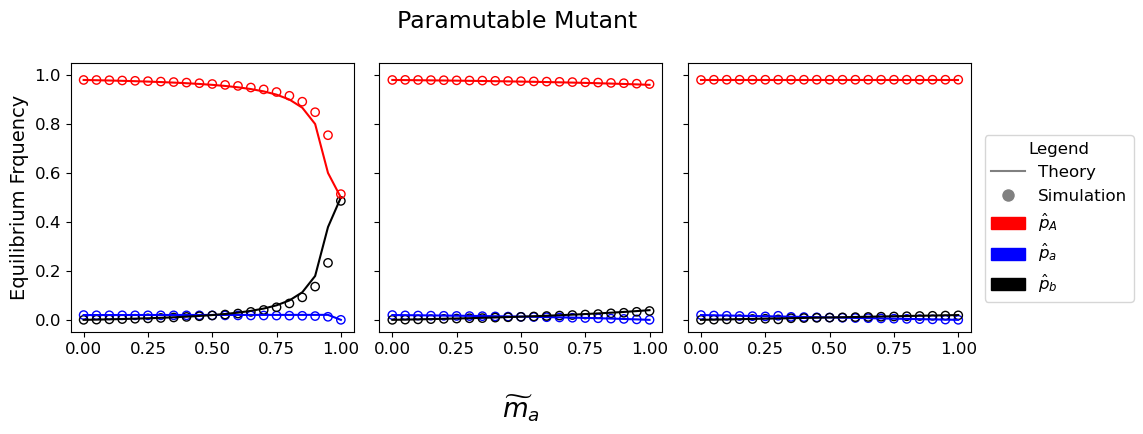

In [73]:
%matplotlib inline
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

hrng = [0,0.5,1]
xrange = np.arange(0,1.01,0.05) 
fig, ax = plt.subplots(1,3, figsize=(10,4.5), sharex = True, sharey = True)

for hind, h in enumerate(hrng): 
    #wAA,waa,wbb,wAa,wAb,wab
    hpre_list = [0,1,h,0.5,h/2,(1+h)/2]
    paramutableMt_plotting(hpre_list, ax[hind], xrange, refined = False)

handles, labels = ax[0].get_legend_handles_labels()
custom_lines = [
    Line2D([0], [0], color='grey', label='Theory'),
    Line2D([0], [0], marker='o', color='w', label='Simulation',markerfacecolor='grey', markersize=10),
    Patch(facecolor='red', edgecolor='red',  label=r"$\hat{p}_{A}$"),
    Patch(facecolor='blue', edgecolor='blue',  label=r"$\hat{p}_{a}$"),
    Patch(facecolor='black', edgecolor='black',  label=r"$\hat{p}_{b}$")    
]


fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.15,0.7),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency")
ax[1].set_xlabel("\n"+r"$\widetilde{m}_a$", fontsize=19)
ax[1].set_title("Paramutable Mutant \n")
plt.tight_layout()
plt.savefig('ParamutableMutant_Supp.png',format='png',bbox_inches='tight')
plt.show()

In [43]:
def prechange_paramutableWt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    
    pA = 1
    pB = 0
    pa = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        
        pas = (waa*pa+wAa*pA+waB*pB)*pa
        pAs = (wAa*pa+wAA*pA+wAB*pB)*pA
        pBs = (waB*pa+wAB*pA+wBB*pB)*pB
        
        pamut = (1-mu)*pas + mu*pAs + nu*pBs 
        pAmut = (1-mu)*pAs - mApre*(1-mu)*pA*(wAa*pa+wAB*pB) + tApre*(1-nu)*pBs + mu*pBs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pA*(wAa*pa+wAB*pB)
        
        wavg = pamut + pAmut + pBmut    
        
        pAnext = pAmut/wavg
        panext = pamut/wavg
        pBnext = 1-round(pAnext+panext,5)
        
        if round(panext + pAnext + pBnext,5) > 1:
            print("Negatives imminent", panext + pAnext+ pBnext)     
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pa = panext 
        pB = pBnext 
        
        if pA < 0 or pa <0 or pB <0 : 
            raise TypeError("Negativesss", [pAs, pAmut, pA], [pas, pamut, pa], [pBs, pBmut, pB])
        
        if timeseries: 
            pAlist += [pA]
            palist += [pa]
            pBlist += [pB]
            
    if timeseries: 
        return [pAlist, palist, pBlist, pA, pa, pB]
    
    return [pAnext,panext,pBnext]

def prechange_paramutableWt_analytic_refined(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    tAtilde = tApre/(tApre+mApre)
    mAtilde = mApre/(tApre+mApre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if waB == waa and wBB == waa and wAB == wAa: 
        s = wAA - waa 
        h = (wAA - wAa)/(wAA - waa)
        pa_genetic = mu/(wAA-wAa) if wAA-wAa != 0 else np.sqrt(mu/(wAA-waa))
        
        if h == 0: 
            if mAtilde <= 0.48: 
                pa_equi = pa_genetic*np.sqrt((tAtilde-mAtilde)/tAtilde) 

            elif mAtilde >= 0.52 and mAtilde <= 0.9 : 
                pa_equi = mAtilde*((2*mAtilde-1)*nu+mu*tAtilde)/(s*tAtilde*(2*mAtilde-1))

            elif 0.9 < round(mAtilde,4) < 1 : 
                A = 0.5 + (mu + nu)/(2*(1-h)*s*tAtilde) 
                B = nu/((1-h)*s*tAtilde)
                pa_equi = A - np.sqrt(A**2-B)
            
            elif round(mAtilde,4) == 1 :
                pa_equi = mu/(mu+nu)
            else:
                pa_equi = float('nan')
        
        else : 
            if mAtilde < 0.45: 
                pa_equi = pa_genetic
                
            elif mAtilde <= 0.9:
                pa_equi = (2*mu*tAtilde + nu*(1-2*tAtilde))/(2*s*tAtilde*(2*tAtilde*h+(1-2*tAtilde)*(1-h)))
            
            #elif mAtilde <= 0.9: 
            #    pa_equi = (tAtilde*mu+(mAtilde-tAtilde)*nu)/(tAtilde*s)*(mAtilde/((1-h)*mAtilde-(1-2*h)*tAtilde))
            
            elif mAtilde != 1 and h != 1 : 
                A = 0.5 + (mu + nu)/(2*(1-h)*s*tAtilde) 
                B = nu/((1-h)*s*tAtilde)
                pa_equi = A - np.sqrt(A**2-B)
            else: 
                pa_equi = mu/(mu+nu)
                
                
                
            """
            if mAtilde < 0.45: 
                pa_equi = pa_genetic
                
            elif 0.45 <= mAtilde <= 0.9 and h==1:
                pa_equi = (2*mu*tAtilde + nu*(1-2*tAtilde))/(2*s*tAtilde*(2*tAtilde*h+(1-2*tAtilde)*(1-h)))
                
            #elif mAtilde > 0.55 and mAtilde <= 0.9 : 
            #    pa_equi = (tAtilde*mu+(mAtilde-tAtilde)*nu)/(tAtilde*s)*(mAtilde/((1-h)*mAtilde-(1-2*h)*tAtilde))

            elif round(mAtilde,4) != 1 and h != 1: 
                A = 0.5 + (mu + nu)/(2*(1-h)*s*tAtilde) 
                B = nu/((1-h)*s*tAtilde)
                pa_equi = A - np.sqrt(A**2-B)
            else:
                pa_equi = mu/(mu+nu) 
            """ 
                
        """
        if mAtilde < 0.45: 
            if h != 0 : 
                pa_equi = pa_genetic
            else : 
                pa_equi = pa_genetic*np.sqrt((tAtilde-mAtilde)/tAtilde) 
        
        elif round(mAtilde,4) == 0.5 and h == 0: 
            pa_equi = np.sqrt(8/5*mu/s)
        
        elif 0.45 <= mAtilde <= 0.55:
            pa_equi = (tAtilde*mu+(mAtilde-tAtilde)*nu)/(tAtilde*s)*(mAtilde/((1-h)*mAtilde-(1-2*h)*tAtilde))
        
        elif mAtilde > 0.55 and mAtilde <= 0.9 : 
            if h!= 0 :
                pa_equi = (2*mu*tAtilde + nu*(1-2*tAtilde))/(2*s*tAtilde*(2*tAtilde*h+(1-2*tAtilde)*(1-h)))
            else:
                pa_equi = ((2*mAtilde-1)*nu+mu*tAtilde)/(s*tAtilde*(2*mAtilde-1))
        
        elif round(mAtilde,4) != 1 and h != 1: 
            A = 0.5 + (mu + nu)/(2*(1-h)*s*tAtilde) 
            B = nu/((1-h)*s*tAtilde)
            pa_equi = A - np.sqrt(A**2-B)
        else:
            pa_equi = mu/(mu+nu) 
        """
    else: 
        return [0,0,0]
    if 1 - 4*(1-pa_equi)*tAtilde*mAtilde < 0 : 
        print(1 - 4*(1-pa_equi)*tAtilde*mAtilde, mAtilde, pa_equi)
                                            
    fA = (1 - np.sqrt(1 - 4*(1-pa_equi)*tAtilde*mAtilde))/(2*(1-pa_equi)*mAtilde) if mAtilde !=0 else 1
    fB = 1-fA
    pA = fA*(1-pa_equi)
    pB = fB*(1-pa_equi)
    
    #print(pa_equi)
    return pa_equi, pA, pB

def prechange_paramutableWt_analytic(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    tAtilde = tApre/(tApre+mApre)
    mAtilde = mApre/(tApre+mApre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if mAtilde <= 0.5: 
        fB = 0 
    else: 
        fB = 1 - tAtilde/mAtilde
    fA = 1 - fB 
    
    wAAeff = fA**2*wAA + 2*fA*fB*wAB + fB**2*wBB
    wAaeff = fA*wAa + fB*waB 
    waaeff = waa
    
    
    mueff = mu*tAtilde + nu*mAtilde 
    
    if wAAeff > wAaeff : 
        #print('1')
        pa_equi = mueff*wAAeff/(wAAeff - wAaeff)
    elif wAAeff == wAaeff > waaeff: 
        #print('2')
        pa_equi = np.sqrt(mueff/(wAAeff - waaeff))
    elif wAAeff < wAaeff < waaeff : 
        #print('3')
        pa_equi = 1 - mu/(waaeff - wAaeff)
    elif wAAeff < wAaeff == waaeff: 
        #print('4')
        pa_equi = 1 - np.sqrt(mu/(waaeff - wAAeff))
    elif wAAeff < wAaeff > waaeff: 
        #print('5')
        pa_equi = (wAAeff - wAaeff) / (wAAeff + waaeff - 2*wAaeff) + mueff/(wAaeff-wAAeff) + mu/(waaeff-wAaeff)
    else: 
        #print('6')
        pa_equi = mueff/(mueff + mu)
    
    fA = (1 - np.sqrt(1 - 4*(1-pa_equi)*tAtilde*mAtilde))/(2*(1-pa_equi)*mAtilde) if mAtilde !=0 else 1
    fB = 1-fA
    pA = fA*(1-pa_equi)
    pB = fB*(1-pa_equi)
    
    #print(pa_equi)
    return pa_equi, pA, pB

def paramutableWt_plotting(hpre_list, ax, x_range, refined = True):
    #wAA,waa,wBB,wAa,wAB,waB 
    #hpre_list = [0,1] + [np.random.random() for i in range(4)]
    spre = 0.01
    mu = 10**(-4)
    nu = 10**(-4)
    NoG = 10**5

    pa_theory_list = []
    pA_theory_list = []
    
    pa_refined_theory_list = []
    pA_refined_theory_list = []
    
    pa_list = []
    pA_list = []


    slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
    for x in x_range: 
        x = round(x,4)
        #print(x)
        mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
        tApre = (1-x)*mApre/x if x != 0 else np.random.random()

        pa_theory, pA_theory, pB_theory = prechange_paramutableWt_analytic(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=NoG)
        pa_refined_theory, pA_refined_theory, pB_refined_theory = prechange_paramutableWt_analytic_refined(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=NoG)
        
        pAlist, palist, pBlist, pA, pa, pB = prechange_paramutableWt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=True, NoG=NoG)
        pa_list += [pa]
        pA_list += [pA]

        pa_theory_list += [pa_theory]
        pA_theory_list += [pA_theory]
        
        pa_refined_theory_list += [pa_refined_theory]
        pA_refined_theory_list += [pA_refined_theory]
    
    if refined == True: 
        ax.plot(x_range, pa_refined_theory_list, color = "blue", linestyle = '--')
        ax.plot(x_range, pA_refined_theory_list, color = "red", linestyle = '--')
        ax.plot(x_range, 1- np.array(pA_refined_theory_list) - np.array(pa_refined_theory_list), color = "black", linestyle = '--')

    
    ax.scatter(x_range, pa_list, c = "none",edgecolors= "blue")
    ax.scatter(x_range, pA_list, c = "none",edgecolors= "red")
    ax.scatter(x_range,1 - np.array(pA_list) - np.array(pa_list), c = "none",edgecolors= "black")
    
    
    ax.plot(x_range, 1 -np.array(pA_theory_list) - np.array(pa_theory_list), color = "black")
    ax.plot(x_range, pA_theory_list, color = "red")
    ax.plot(x_range, pa_theory_list, color = "blue")
    
    #ax.axhline(y=0, linestyle = '--')
    
    return 0 


5444


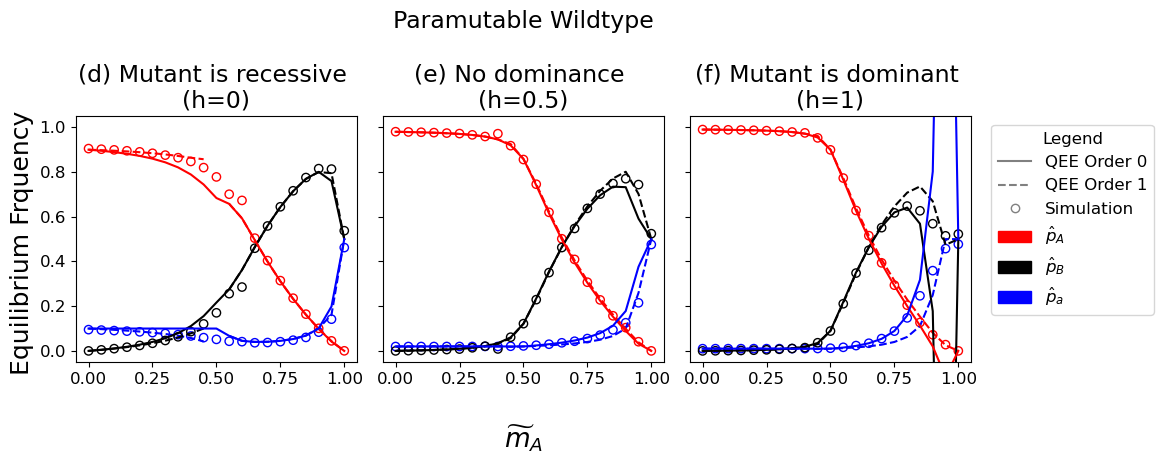

In [130]:
%matplotlib inline
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sd = round(10**4*np.random.random()) #8193 is weird #5563 is medium #4857 is good
np.random.seed(4857)
print(sd)

hrng = [0,0.5,1]
xrange = np.arange(0,1.01,0.05) 
fig, ax = plt.subplots(1,3, figsize=(10,4.8), sharex = True, sharey = True)

for hind, h in enumerate(hrng): 
    hpre_list = [0,1,1,h,h,1]
    paramutableWt_plotting(hpre_list, ax[hind], xrange)

handles, labels = ax[0].get_legend_handles_labels()
custom_lines = [
    Line2D([0], [0], color='grey', label='QEE Order 0'),
    Line2D([0], [0], color='grey', linestyle = '--', label='QEE Order 1'),
    Line2D([0], [0], marker='o', color='w', label='Simulation',markerfacecolor='none',markeredgecolor='grey'),
    Patch(facecolor='red', edgecolor='red',  label=r"$\hat{p}_{A}$"),
    Patch(facecolor='black', edgecolor='black',  label=r"$\hat{p}_{B}$"),
    Patch(facecolor='blue', edgecolor='blue',  label=r"$\hat{p}_{a}$")    
]
fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.17,0.74),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency ", fontsize=18)
ax[1].set_xlabel("\n"+r"$\widetilde{m}_A$", fontsize=19)
ax[1].set_title(r"Paramutable Wildtype" + "\n\n(e) No dominance \n(h=0.5)")
ax[0].set_title("(d) Mutant is recessive \n(h=0)")
ax[2].set_title("(f) Mutant is dominant \n(h=1)")
plt.tight_layout()



"""
fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.17,0.74),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency")
ax[1].set_xlabel("\n"+r"$\widetilde{m}_A$", fontsize=19)

ax[0].set_title("h = 0")
ax[1].set_title("Paramutable Wildtype \n \n h = 0.5")
ax[2].set_title("h = 1")
#plt.ylim((0,0.1))
plt.tight_layout()
#
"""
plt.savefig('ParamutableWildtype.png',format='png',bbox_inches='tight')
plt.show()

In [76]:
fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.17,0.74),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency")
ax[1].set_xlabel("\n"+r"$\widetilde{m}_A$", fontsize=19)

ax[0].set_title("h = 0")
ax[1].set_title("Paramutable Wildtype \n \n h = 0.5")
ax[2].set_title("h = 1")
#plt.ylim((0,0.1))
plt.tight_layout()
#plt.savefig('ParamutableWildtype.png',format='png',bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

2410


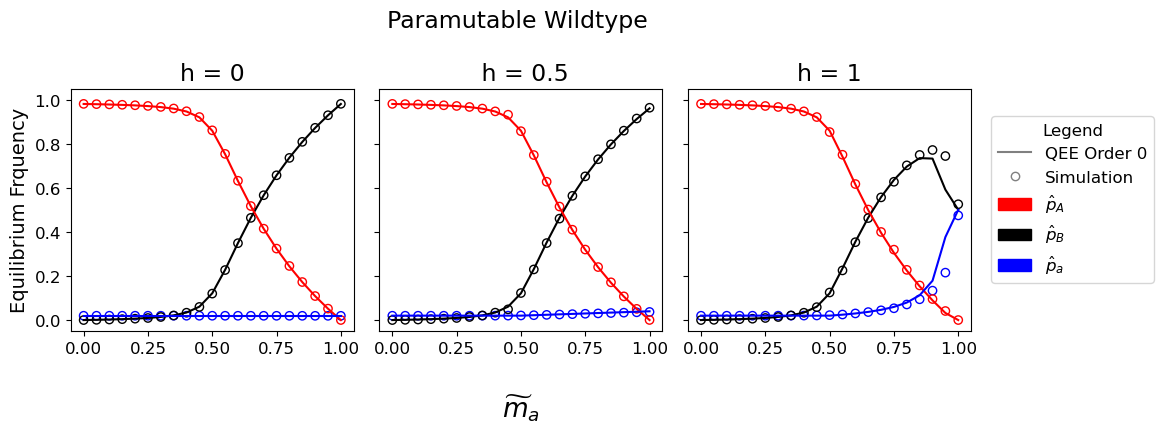

In [46]:
%matplotlib inline
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sd = round(10**4*np.random.random()) #8193 is weird #5563 is medium #4857 is good
np.random.seed(sd)
print(sd)

hrng = [0,0.5,1]
xrange = np.arange(0,1.01,0.05) 
fig, ax = plt.subplots(1,3, figsize=(10,4.5), sharex = True, sharey = True)

for hind, h in enumerate(hrng): 
    #wAA,waa,wBB,wAa,wAB,waB 
    hpre_list = [0,1,h,0.5,h/2,(1+h)/2]
    paramutableWt_plotting(hpre_list, ax[hind], xrange, refined = 'False')

handles, labels = ax[0].get_legend_handles_labels()
custom_lines = [
    Line2D([0], [0], color='grey', label='QEE Order 0'),
    Line2D([0], [0], marker='o', color='w', label='Simulation',markerfacecolor='none',markeredgecolor='grey'),
    Patch(facecolor='red', edgecolor='red',  label=r"$\hat{p}_{A}$"),
    Patch(facecolor='black', edgecolor='black',  label=r"$\hat{p}_{B}$"),
    Patch(facecolor='blue', edgecolor='blue',  label=r"$\hat{p}_{a}$")    
]


fig.legend(handles=custom_lines , loc='upper right',bbox_to_anchor=(1.17,0.74),title = 'Legend')      
ax[0].set_ylim((-0.05,1.05))
ax[0].set_ylabel(r"Equilibrium Frquency")
ax[1].set_xlabel("\n"+r"$\widetilde{m}_a$", fontsize=19)

ax[0].set_title("h = 0")
ax[1].set_title("Paramutable Wildtype \n \n h = 0.5")
ax[2].set_title("h = 1")
plt.tight_layout()
plt.savefig('ParamutableWildtype_Supp.png',format='png',bbox_inches='tight')
plt.show()

## Diploid Evolutionary Rescue

### Epimutation 

0.010000000000000009
0.008850000000000136
0.007799999999999918
0.006850000000000134
0.005999999999999783
0.005249999999999977
0.0046000000000000485
0.004049999999999776
0.0035999999999999366
0.003249999999999864
0.0030000000000001137
0.002850000000000019
0.0027999999999995806
0.002849999999999686
0.0029999999999998916
0.003249999999999975
0.0035999999999999366
0.004049999999999887
0.0045999999999999375
0.005250000000000088
0.006000000000000005
0.010000000000000009
0.008850000000000025
0.007799999999999918
0.006850000000000134
0.005999999999999783
0.005249999999999977
0.0046000000000000485
0.004049999999999998
0.0035999999999999366
0.003249999999999864
0.0030000000000001137
0.002850000000000019
0.0027999999999999137
0.0028500000000002412
0.0029999999999996696
0.003249999999999975
0.0036000000000000476
0.004049999999999887
0.0045999999999999375
0.005250000000000088
0.006000000000000005
0.010000000000000009
0.008850000000000136
0.007800000000000251
0.006849999999999912
0.00599999999999978

AttributeError: 'Axes' object has no attribute 'set_y'

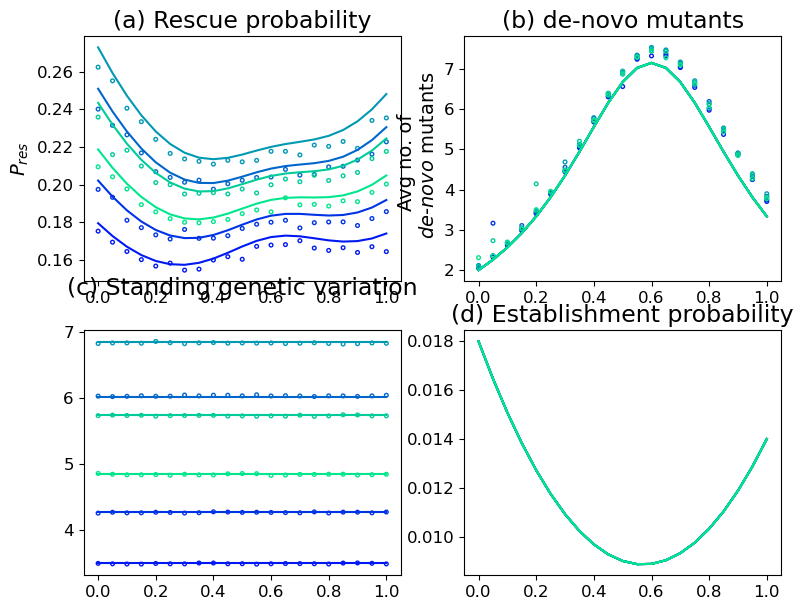

In [7]:
def Pres_diploid(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    
    mApost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tApost = (1-y)*mApost/y if y != 0 else np.random.random()
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mapost/y if y != 0 else np.random.random()
    
    output = prechange_diploid_analytic(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu)
    paeff_sgv = output[-1]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv, pasgv, pbsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre), paeff_sgv*tapre/(mapre+tapre), paeff_sgv*mapre/(mapre+tapre)
    
    
    lamAA,lamaa,lamBB,lambb,lamAa,lamAB,lamAb,lamaB,lamab,lamBb = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = mApost/(mApost+tApost) 
    mapost_tilde = mapost/(mapost+tapost) 
    tApost_tilde = tApost/(mApost+tApost) 
    tapost_tilde = tapost/(mapost+tapost) 
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*tapost_tilde*lamAa + tApost_tilde*mapost_tilde*lamAb + mApost_tilde*tapost_tilde*lamaB + mApost_tilde*mapost_tilde*lamBb
    lamaaeff = tapost_tilde**2*lamaa + 2*mapost_tilde*tapost_tilde*lamab + mapost_tilde**2*lambb 
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*2*Nstart)
        NumMutants = mueff/reff*2*Nstart
        NumSGV = paeff_sgv*2*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          
fig, ax = plt.subplots(2,2,figsize = (9,7))

x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
cmap = mpl.colormaps['winter']

hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Pres_diploid(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in DiploidDF.transpose().index]
    ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(DiploidDF.transpose().index,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(DiploidDF.transpose().index,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(DiploidDF.transpose().index,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(DiploidDF.transpose().index,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))

ax[0][0].set_title('(a) Rescue probability')
ax[0][1].set_title('(b) de-novo mutants')
ax[1][0].set_title('(c) Standing genetic variation\n')
ax[1][1].set_title('(d) Establishment probability')


ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True


sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r"Post-change epimodification $\widetilde{m}_A\hspace{-0.3}'=\widetilde{m}_{a}\hspace{-0.3}'$")

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label("Pre-change epimodification " + r'$\widetilde{m}_{A}=\widetilde{m}_{a}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()



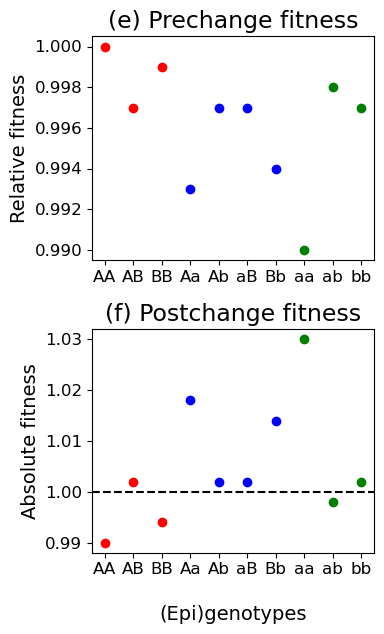

In [79]:
fig, ax = plt.subplots(2,1,figsize = (4,6.5))

wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     

ax[0].scatter(['AA','AB','BAB'], [wAA,wAB,wBB], color = 'red')
ax[0].scatter(['Aa','Ab','aB','Bb'], [wAa,wAb,waB,wBb], color = 'blue')
ax[0].scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
ax[0].set_title('(e) Prechange fitness')
ax[0].set_ylabel('Relative fitness')
#plt.show()

wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-rpost+np.array(hpre_list)*spost

ax[1].scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
ax[1].scatter(['Aa','Ab','aB','Bb'], [wAa,wAb,waB,wBb], color = 'blue')
ax[1].scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
ax[1].axhline(y=1.0,linestyle = '--', color ='black')
ax[1].set_title('(f) Postchange fitness')
ax[1].set_ylabel('Absolute fitness')
ax[1].set_xlabel('\n(Epi)genotypes')
plt.tight_layout()
plt.savefig('Diploid_ER_Fitness.png',format='png')
plt.show()


### Paramutation - Paramutable Wildtype

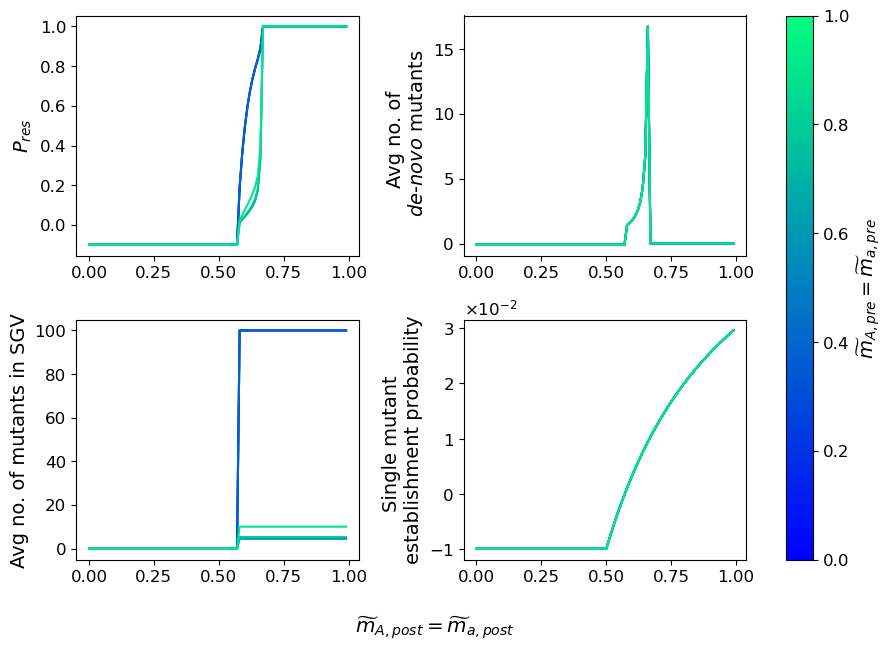

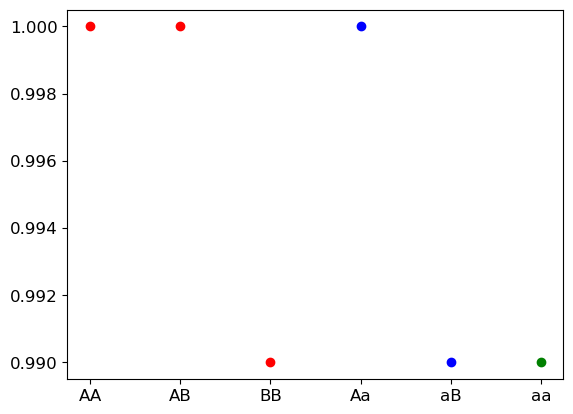

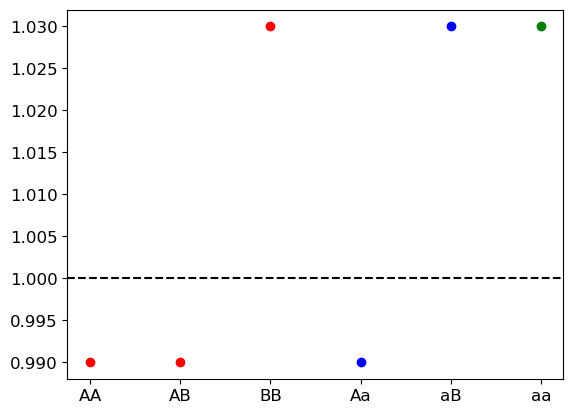

In [80]:
def Pres_paramutableWt(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    
    mApost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tApost = (1-y)*mApost/y if y != 0 else np.random.random()
    
    output = prechange_paramutableWt_analytic(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5)
    paeff_sgv = output[0]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre)
    
    lamAA,lamaa,lamBB,lamAa,lamAB,lamaB = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = 1 - tApost/mApost if mApost >= tApost else 0
    tApost_tilde = 1 - mApost_tilde
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*lamAa + mApost_tilde*lamaB 
    lamaaeff = lamaa
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0 and reff >0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    elif reff < 0: 
        Pres = 1
        NumMutants = 0
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          
    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
y_range = np.arange(0,1,0.01)
cmap = mpl.colormaps['winter']


h=0

hpre_list = [0,1] + [np.random.random() for x in range(4)]
hpre_list = [0,1,1,h,h,1]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    #DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    #DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Pres_paramutableWt(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    #ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    #ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.show()

wAA,waa,wBB,wAa,wAB,waB = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()

## Paramutation - Paramutable Mutant 

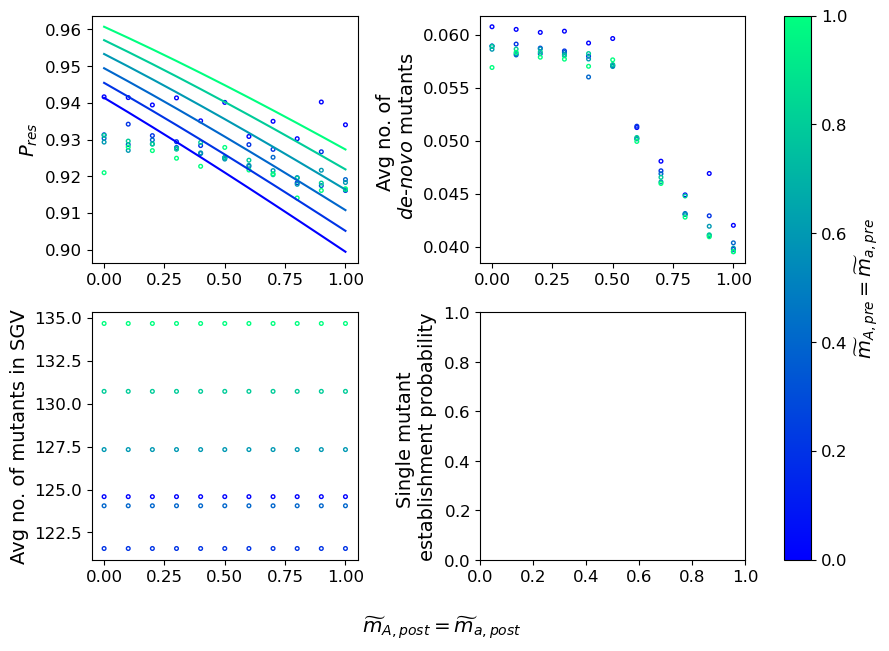

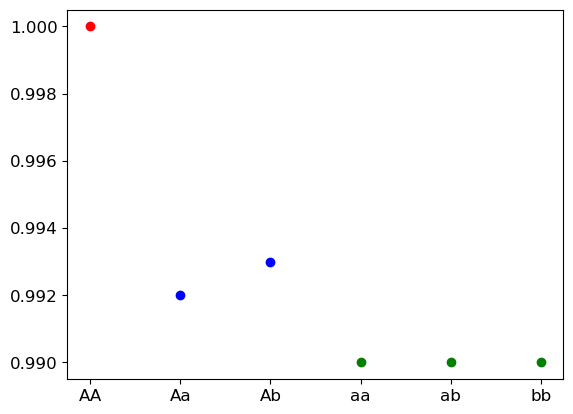

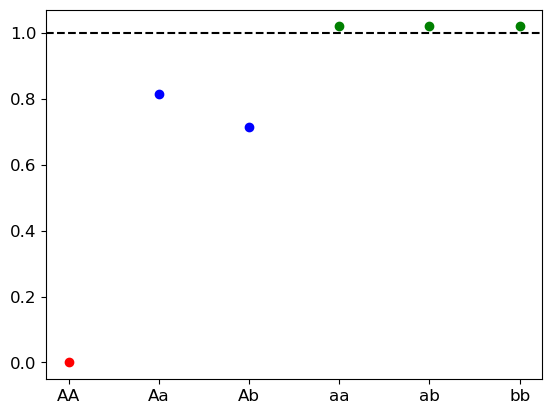

In [81]:
def Pres_paramutableMt(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mapost/y if y != 0 else np.random.random()
    
    
    
    output = prechange_paramutableMt_analytic(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5)
    #paeff_sgv = output[1] + output[2] 
    #pA_sgv = 1 - paeff_sgv
    
    paeff_sgv = sum(output)
    pA_sgv = 1-paeff_sgv
    
    lamAA,lamaa,lambb,lamAa,lamAb,lamab = 1 - rpost + np.array(hpost_list)*spost
    
    mapost_tilde = mapost/(mapost+tapost)
    #print(mapost_tilde)
    tapost_tilde = 1 - mapost_tilde
    
    lamaaeff = tapost_tilde**2*lamaa + 2*mapost_tilde*tapost_tilde*lamab + mapost_tilde**2*lambb 
    lamAaeff = tapost_tilde*lamAa + mapost_tilde*lamAb
    lamAAeff = lamAA
    
    reff = 1 - lamAAeff 
    mueff = mapost_tilde*nu + tapost_tilde*mu 
    sAaeff = lamAaeff - 1
    saaeff = lamaaeff - 1
    #print(reff)
    if sAaeff > 0 and reff > 0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart -2*saaeff*(paeff_sgv**2)*Nstart  )
        
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    
    elif reff == 1 : 
        if sAaeff < 0: 
            pAasgv = 2*paeff_sgv*(1-paeff_sgv)
            Pres = 1 - np.exp(-2*saaeff*( 0.5*pAasgv*Nstart*(0.25+2*mueff)/(0.25+2*mueff-sAaeff) + paeff_sgv**2 ))
            NumMutants = 0
            NumSGV = 0
    else:
        Pres = -1
        NumMutants = -1
        NumSGV = -1
    
    
    
    return Pres, NumMutants, NumSGV, sAaeff
                          
    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = np.arange(0,1.01,0.2)
y_range = np.arange(0,1.01,0.1)

#x_range = np.arange(0,1,0.4)
#y_range = np.arange(0,1,0.1)

cmap = mpl.colormaps['winter']



hpre_list = [0,1] + [np.random.random() for x in range(4)]
#wAA,waa,wbb,wAa,wAb,wab
#hpre_list = [0, 1, 0.48, 0.47, 0.4, 0.27]
hpre_list = [0, 1, 1, 0.8, 0.7, 1]
hpost_list = hpre_list


spre = 0.01 
spost = 1+0.02
rpost = 1 #0.01
mu = 10**(-4)
nu = 10**(-4)
Nstart = 10**4
%matplotlib inline
for x in x_range:     
    ParamutableMtERwriter = pd.ExcelFile('./DataFiles/ParamutableMutant_ER_1.xlsx')
    ExtDF = pd.read_excel(ParamutableMtERwriter, sheet_name = 'RescueProb' ,index_col=0)
    SGVDF = pd.read_excel(ParamutableMtERwriter, sheet_name = 'SGV' ,index_col=0)
    DNMDF = pd.read_excel(ParamutableMtERwriter, sheet_name = 'DNM' ,index_col=0)
    
    Pres_theory = [Pres_paramutableMt(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    ax[0][0].scatter(ExtDF.transpose().index,1-ExtDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    ax[0][1].scatter(DNMDF.transpose().index,DNMDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    #ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][0].scatter(SGVDF.transpose().index,SGVDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    #ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre     

plt.scatter(['AA'], [wAA], color = 'red')
plt.scatter(['Aa','Ab'], [wAa,wAb], color = 'blue')
plt.scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
plt.show()

lamAA,lamaa,lambb,lamAa,lamAb,lamab = 1 - rpost + np.array(hpost_list)*spost

plt.scatter(['AA'], [lamAA], color = 'red')
plt.scatter(['Aa','Ab'], [lamAa,lamAb], color = 'blue')
plt.scatter(['aa','ab','bb'], [lamaa,lamab,lambb], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()

0

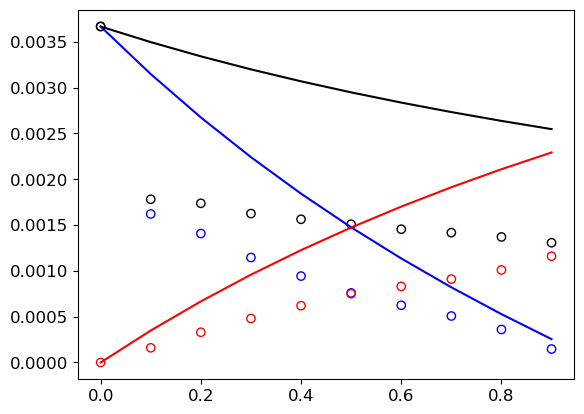

In [82]:
hpre_list = [0, 1, 0.28, 0.27, 0.4, 0.27]
def paramutableMt_plotting_2(hpre_list, ax, x_range, refined=True):
    #wAA,waa,wbb,wAa,wAb,wab
    #hpre_list = [0,1] + [np.random.random() for i in range(4)]
    spre = 0.01
    mu = 10**(-5)
    nu = 10**(-5)
    NoG = 10**6

    pa_theory_list = []
    pb_theory_list = []
    
    pa_refined_theory_list = []
    pb_refined_theory_list = []
    
    pa_list = []
    pb_list = []


    slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
    for x in x_range: 
        x = round(x,4)
        #print(x)
        mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
        tapre = (1-x)*mapre/x if x != 0 else np.random.random()

        pa_theory, pb_theory = prechange_paramutableMt_analytic(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=NoG)
        
        if refined == True:
            pa_refined_theory, pb_refined_theory = prechange_paramutableMt_analytic_refined(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=NoG)
            pa_refined_theory_list += [pa_refined_theory]
            pb_refined_theory_list += [pb_refined_theory]
        
        pAlist, palist, pblist, pA, pa, pb = prechange_paramutableMt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=True, NoG=NoG)

        pa_list += [pa]
        pb_list += [pb]

        pa_theory_list += [pa_theory]
        pb_theory_list += [pb_theory]
        
    
    if refined == True: 
        ax.plot(x_range, pa_refined_theory_list, linestyle = '--', color = "blue",label=r"$\hat{p}_{a}$-Theory")
        ax.plot(x_range, pb_refined_theory_list, linestyle = '--', color = "red",label=r"$\hat{p}_{b}$-Theory")
        ax.plot(x_range, 1- np.array(pb_refined_theory_list) - np.array(pa_refined_theory_list), linestyle = '--', color = "black",label=r"$\hat{p}_{b}$-Theory")
    
    ax.plot(x_range, pa_theory_list, color = "blue",label=r"$\hat{p}_{a}$-Theory")
    ax.scatter(x_range, pa_list, c = "none",edgecolors= "blue", label=r"$\hat{p}_{a}$-Simulated" )

    ax.plot(x_range, pb_theory_list, color = "red",label=r"$\hat{p}_{b}$-Theory")
    ax.scatter(x_range, pb_list, c = "none",edgecolors= "red", label=r"$\hat{p}_{b}$-Simulated" )
    
    ax.plot(x_range, np.array(pb_theory_list) + np.array(pa_theory_list), color = "black",label=r"$\hat{p}_{b}$-Theory")
    ax.scatter(x_range,np.array(pb_list) + np.array(pa_list), c = "none",edgecolors= "black", label=r"$\hat{p}_{a_{\text{ef}}}$-Simulated" )

    #ax.axhline(y=0, linestyle = '--')
    
    return 0 

x_range = np.arange(0,1,0.1)
paramutableMt_plotting_2(hpre_list, plt, x_range, refined=False)

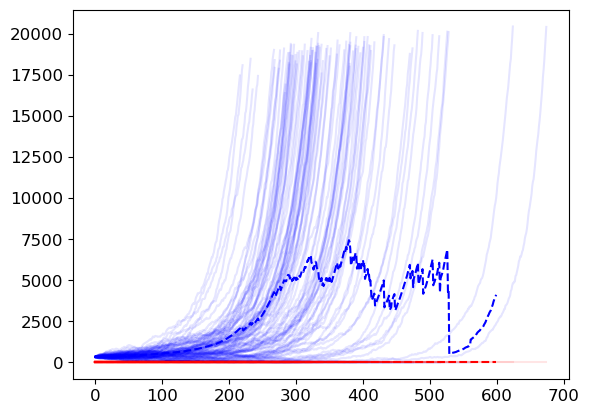

In [83]:
import multiprocessing as mp 
def postchange_paramutableMt_stoch(pA,pa,pb,spost,rpost,hpost_list,mapost,tapost,mu,nu,N_start, timeseries = False) :
    """
    
    Parameters
    ----------
    spre : float (positive)
    spost : float (positive)
    rpost : float (positive)
    hpre_list : list of length 
    hpost_list : list of length
    mapre : float (between 0 and 1)
    mApre : float (between 0 and 1)
    tapre : float (between 0 and 1)
    tApre : float (between 0 and 1)
    mapost : float (between 0 and 1)
    mApost : float (between 0 and 1)
    tapost : float (between 0 and 1)
    tApost : float (between 0 and 1)
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    np.random.seed()
      
    lamAA,lamaa,lambb,lamAa,lamAb,lamab = 1 - rpost + np.array(hpost_list)*spost
    
    Ext = 0 
    
    NA = pA*N_start
    Na = pa*N_start
    Nb = pb*N_start
    
    Nsgv = Na + Nb
    
    NAlist = [NA]
    Nalist = [Na]
    Nblist = [Nb]
    
    Nmut = 0
    while True: 
        N_tot = NA + Na + Nb     
        
        if N_tot == 0:
            Ext = 1
            break
        elif N_tot > 2*max(N_start, 10**4): 
            break
        
        pA = NA/float(N_tot)
        pa = Na/float(N_tot)
        pb = Nb/float(N_tot)
        
        NAs = (lamAA*pA+lamAa*pa+lamAb*pb)*NA
        Nas = (lamAa*pA+lamaa*pa+lamab*pb)*Na
        Nbs = (lamAb*pA+lamab*pa+lambb*pb)*Nb
        
        NAmut = (1-mu)*NAs + mu*Nas + nu*Nbs
        Namut = (1-mu)*Nas - mapost*(1-mu)*Na*(lamAa*pA+lamab*pb) + tapost*(1-nu)*Nbs + mu*NAs 
        Nbmut = (1-tapost)*(1-nu)*Nbs + mapost*(1-mu)*Na*(lamAa*pA+lamab*pb)
        
        Nmut += mu*NAs
        
        NA = np.random.poisson(NAmut)
        Na = np.random.poisson(Namut)
        Nb = np.random.poisson(Nbmut)
        
        if timeseries: 
            NAlist += [NA]
            Nalist += [Na]
            Nblist += [Nb]
        
    if timeseries: 
        return NAlist, Nalist, Nblist, Ext, Nsgv, Nmut
    
    return Ext, Nsgv, Nmut


NoR = 10**2
spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-4)
nu = 10**(-4)
Nstart = 10**4
mapre = 0
mapost = 0
tapre = 0.5
tapost = 0.5 

hpre_list = [0, 1, 0.28, 0.27, 0.4, 0.27]
hpost_list = hpre_list

pA, pa,pb = prechange_paramutableMt_det(spre,hpre_list,mapre,tapre,mu,nu,NoG = 10**5,timeseries=False)

 
a = mp.cpu_count() - 2
pool = mp.Pool(a)
results = pool.starmap(postchange_paramutableMt_stoch, [(pA,pa,pb,spost,rpost,hpost_list,mapost,tapost,mu,nu,Nstart,True) for rep in range(NoR)])
pool.close()
pool.join()

NAlist = [replicate[0] for replicate in results]
Nalist = [replicate[1] for replicate in results]
Nblist = [replicate[2] for replicate in results]

Ext = np.mean([replicate[3] for replicate in results])
Nsgvavg = np.mean([replicate[4] for replicate in results])
Nmutavg = np.mean([replicate[5] for replicate in results])

"""
for NA in NAlist:
    plt.plot(NA, color = 'grey',alpha=0.3)

NAavg = []
for i in range(600):
    NAgen = 0
    for NA in NAlist:
        if i < len(NA) :
            NAgen += NA[i]

    NAavg += [NAgen/100]

plt.plot(NAavg, color = 'black', linestyle = '--')    
lamAA,lamaa,lambb,lamAa,lamAb,lamab = 1 - rpost + np.array(hpost_list)*spost


plt.plot([Nstart*lamAA**t for t in range(600)], color = 'black')
"""


for Na in Nalist:
    plt.plot(Na, color = 'blue',alpha=0.1)

Naavg = []
for i in range(600):
    Nagen = [0]
    for Na in Nalist:
        if i < len(Na) :
            Nagen += [Na[i]]

    Naavg += [np.mean(Nagen)]

plt.plot(Naavg, color = 'blue', linestyle = '--')    

for Nb in Nblist:
    plt.plot(Nb, color = 'red',alpha=0.1)

Nbavg = []
for i in range(600):
    Nbgen = 0
    for Nb in Nblist:
        if i < len(Nb) :
            Nbgen += Nb[i]

    Nbavg += [Nbgen/100]

plt.plot(Nbavg, color = 'red', linestyle = '--')    





In [84]:
lamAa

0.8160000000000001

NameError: name 'analytic_dipparamt_det' is not defined

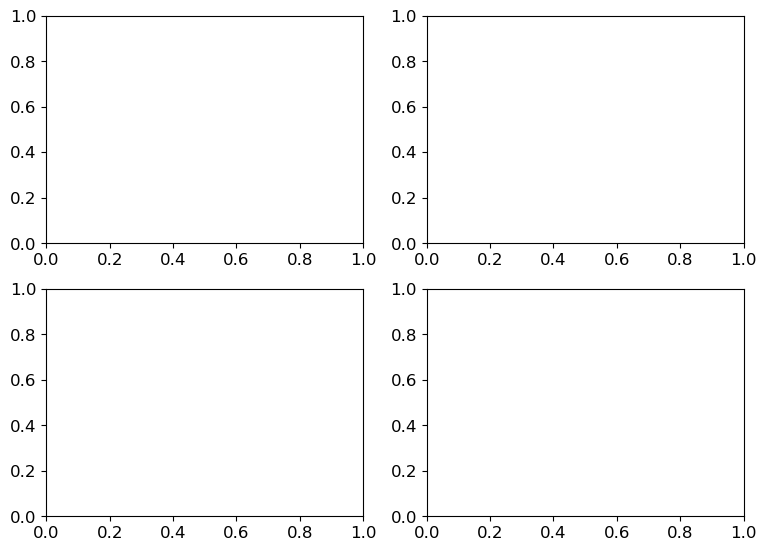

In [85]:
def Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tBpre = (1-x)*mApre/x if x != 0 else np.random.random()
    
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mApost/y if y != 0 else np.random.random()
    
    output = analytic_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5)
    paeff_sgv = output[0]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre)
    
    lamAA,lamaa,lamBB,lamAa,lamAB,lamaB = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = 1 - tApost/mApost if mApost >= tApost else 0
    tApost_tilde = 1 - mApost_tilde
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*lamAa + mApost_tilde*lamaB 
    lamaaeff = lamaa
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0 and reff >0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    elif reff < 0: 
        Pres = 1
        NumMutants = 0
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          

    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
y_range = np.arange(0,1,0.01)
cmap = mpl.colormaps['winter']


h=0.5

hpre_list = [0,1] + [np.random.random() for x in range(4)]
hpre_list = [0,1,1,h,h,1]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    #DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    #DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    #ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    #ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.show()

wAA,waa,wBB,wAa,wAB,waB = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()